# CRM public report routing: image/text embeddings + CatBoost (early fusion experiments)

In [ ]:
DATA_DIR = "../data"

import pandas as pd
import numpy as np
import re
from tqdm import tqdm
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from catboost import CatBoostClassifier, Pool
import torch

from sklearn.model_selection import train_test_split, cross_val_score, RepeatedStratifiedKFold
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    recall_score,
    precision_score,
    balanced_accuracy_score,
    confusion_matrix
)

import datasets
from transformers import (
    AutoFeatureExtractor,
    AutoModel,
    AutoImageProcessor,
    AutoProcessor,
    AutoTokenizer,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


## Helpers

In [ ]:
# Import necessary libraries
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(cb_model, test_df, y_true='dinas_final', y_label='label'):
    # Assuming 'cb_model' is your trained CatBoost model and 'val_df_split' contains the validation data
    # Get the class names from the CatBoost model
    class_names = cb_model.classes_.tolist()

    # Assuming 'val_pool' is the validation data pool and 'predictions' are made using the model
    print("Accuracy: ", accuracy_score(test_df[y_true], test_df[y_label]))

    # Calculate balanced accuracy
    balanced_acc = balanced_accuracy_score(test_df[y_true], test_df[y_label])
    print("Balanced Accuracy:", balanced_acc)

    print("Classification Report:")
    print(classification_report(test_df[y_true], test_df[y_label], target_names=class_names))

    # Generate the confusion matrix
    cm = confusion_matrix(test_df[y_true], test_df[y_label])

    # Plot the confusion matrix using seaborn
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Actual Labels')
    plt.ylabel('Predicted Labels')
    plt.title('Confusion Matrix')
    plt.show()

## Load Dataset

In [ ]:
df = pd.read_csv(f'{DATA_DIR}/data_clean.csv')
df.head()

,report_id,number,date,month,year,image_path,description,location,category,dinas,dinas_clean
0,JK2301010001,1,1,1,23,JK2301010001.jpg,tolong nyalakn lampu pju sering terjadi tawura...,KELURAHAN KALI BARU,Jalan,DINAS BINA MARGA,DINAS BINA MARGA
1,JK2301010002,2,1,1,23,JK2301010002.jpg,mohon di cek dan di tindak sesuai peraturan ap...,KELURAHAN ROROTAN,Gangguan Ketenteraman dan Ketertiban,"DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN","DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN"
2,JK2301010003,3,1,1,23,JK2301010003.jpg,Selama ada nya plang segel masih berlanjut kar...,KELURAHAN ROROTAN,Gangguan Ketenteraman dan Ketertiban,"DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN","DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN"
3,JK2301010006,6,1,1,23,JK2301010006.jpg,tolong diperbaiki lampu jalan utama terimakasi...,KELURAHAN SEMANAN,Pekerja Penanganan Prasarana dan Sarana Umum K...,DINAS BINA MARGA,DINAS BINA MARGA
4,JK2301010007,7,1,1,23,JK2301010007.jpg,tolong diperbaiki lampu jalan utama terimakasi...,KELURAHAN SEMANAN,Pekerja Penanganan Prasarana dan Sarana Umum K...,DINAS BINA MARGA,DINAS BINA MARGA


In [ ]:
df["image"] = f"{DATA_DIR}/photo/photo/" + df["image_path"]
df.head()

,report_id,number,date,month,year,image_path,description,location,category,dinas,dinas_clean,image
0,JK2301010001,1,1,1,23,JK2301010001.jpg,tolong nyalakn lampu pju sering terjadi tawura...,KELURAHAN KALI BARU,Jalan,DINAS BINA MARGA,DINAS BINA MARGA,/kaggle/input/gemastik2024/photo/photo/JK23010...
1,JK2301010002,2,1,1,23,JK2301010002.jpg,mohon di cek dan di tindak sesuai peraturan ap...,KELURAHAN ROROTAN,Gangguan Ketenteraman dan Ketertiban,"DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN","DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN",/kaggle/input/gemastik2024/photo/photo/JK23010...
2,JK2301010003,3,1,1,23,JK2301010003.jpg,Selama ada nya plang segel masih berlanjut kar...,KELURAHAN ROROTAN,Gangguan Ketenteraman dan Ketertiban,"DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN","DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN",/kaggle/input/gemastik2024/photo/photo/JK23010...
3,JK2301010006,6,1,1,23,JK2301010006.jpg,tolong diperbaiki lampu jalan utama terimakasi...,KELURAHAN SEMANAN,Pekerja Penanganan Prasarana dan Sarana Umum K...,DINAS BINA MARGA,DINAS BINA MARGA,/kaggle/input/gemastik2024/photo/photo/JK23010...
4,JK2301010007,7,1,1,23,JK2301010007.jpg,tolong diperbaiki lampu jalan utama terimakasi...,KELURAHAN SEMANAN,Pekerja Penanganan Prasarana dan Sarana Umum K...,DINAS BINA MARGA,DINAS BINA MARGA,/kaggle/input/gemastik2024/photo/photo/JK23010...


In [ ]:
top_n = 8
value_counts = df['dinas_clean'].value_counts()
top_n_values = set(value_counts.nlargest(top_n).index)
def finalize_dinas(cur_dinas: str, top_n_values: set) -> str:
    if cur_dinas not in top_n_values:
        return "other"
    else:
        return cur_dinas

df['dinas_final'] = df['dinas_clean'].apply(lambda x: finalize_dinas(x, top_n_values))
df.head()

,report_id,number,date,month,year,image_path,description,location,category,dinas,dinas_clean,image,dinas_final
0,JK2301010001,1,1,1,23,JK2301010001.jpg,tolong nyalakn lampu pju sering terjadi tawura...,KELURAHAN KALI BARU,Jalan,DINAS BINA MARGA,DINAS BINA MARGA,/kaggle/input/gemastik2024/photo/photo/JK23010...,DINAS BINA MARGA
1,JK2301010002,2,1,1,23,JK2301010002.jpg,mohon di cek dan di tindak sesuai peraturan ap...,KELURAHAN ROROTAN,Gangguan Ketenteraman dan Ketertiban,"DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN","DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN",/kaggle/input/gemastik2024/photo/photo/JK23010...,"DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN"
2,JK2301010003,3,1,1,23,JK2301010003.jpg,Selama ada nya plang segel masih berlanjut kar...,KELURAHAN ROROTAN,Gangguan Ketenteraman dan Ketertiban,"DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN","DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN",/kaggle/input/gemastik2024/photo/photo/JK23010...,"DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN"
3,JK2301010006,6,1,1,23,JK2301010006.jpg,tolong diperbaiki lampu jalan utama terimakasi...,KELURAHAN SEMANAN,Pekerja Penanganan Prasarana dan Sarana Umum K...,DINAS BINA MARGA,DINAS BINA MARGA,/kaggle/input/gemastik2024/photo/photo/JK23010...,DINAS BINA MARGA
4,JK2301010007,7,1,1,23,JK2301010007.jpg,tolong diperbaiki lampu jalan utama terimakasi...,KELURAHAN SEMANAN,Pekerja Penanganan Prasarana dan Sarana Umum K...,DINAS BINA MARGA,DINAS BINA MARGA,/kaggle/input/gemastik2024/photo/photo/JK23010...,DINAS BINA MARGA


In [ ]:
df.dinas_final.value_counts()

dinas_final
DINAS BINA MARGA                                 10526
SATUAN POLISI PAMONG PRAJA                       10424
DINAS PERHUBUNGAN                                 9351
KELURAHAN                                         8914
DINAS PERTAMANAN DAN HUTAN                        5405
other                                             4471
DINAS SUMBER DAYA AIR                             1872
DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN     1519
BADAN PEMBINAAN BADAN USAHA MILIK DAERAH          1403
Name: count, dtype: int64

## Embedding

In [ ]:
def extract_img_embeddings(model, feature_extractor, image_name="image"):
    """
    Utility to compute embeddings.
    Args:
        model: huggingface model
        feature_extractor: huggingface feature extractor
        image_name: name of the image column in the dataset
    Returns:
        function to compute embeddings
    """
    device = model.device
    def pp(batch):
        images = batch[image_name]
        inputs = feature_extractor(
            images=[x.convert("RGB") for x in images], return_tensors="pt"
        ).to(device)
        embeddings = model(**inputs).last_hidden_state[:, 0].cpu()
        return {"embedding": embeddings}
    return pp

def huggingface_img_embedding(
    df,
    image_name="image",
    modelname="google/vit-base-patch16-224",
    batched=True,
    batch_size=24,
):
    """
    Compute embeddings using huggingface models.
    Args:
        df: dataframe with images
        image_name: name of the image column in the dataset
        modelname: huggingface model name
        batched: whether to compute embeddings in batches
        batch_size: batch size
    Returns:
        new dataframe with embeddings
    """
    # initialize huggingface model
    feature_extractor = AutoImageProcessor.from_pretrained(modelname)
    model = AutoModel.from_pretrained(modelname, output_hidden_states=True)
    # create huggingface dataset from df
    dataset = datasets.Dataset.from_pandas(df).cast_column(image_name, datasets.Image())
    # compute embedding
    device = "cuda" if torch.cuda.is_available() else "cpu"
    extract_fn = extract_img_embeddings(model.to(device), feature_extractor, image_name)
    updated_dataset = dataset.map(extract_fn, batched=batched, batch_size=batch_size)
    df_temp = updated_dataset.to_pandas()
    df_emb = pd.DataFrame()
    df_emb["embedding"] = df_temp["embedding"]
    return df_emb


def extract_text_embeddings(
    model,
    feature_extractor,
    text_name="description",
):
    device = model.device
    def pp(batch):
        inputs = feature_extractor(
            text=batch[text_name],
            return_tensors="pt"
        ).to(device)
        embeddings = model(**inputs).last_hidden_state[:, 0, :].cpu()
        return {"embedding": embeddings}
    return pp

def huggingface_text_embedding(
    df,
    text_name="description",
    modelname="indonlp/cendol-mt5-base-inst",
    batched=True,
    batch_size=24,
):
    # initialize huggingface model
    feature_extractor = AutoTokenizer.from_pretrained(modelname)
    model = AutoModel.from_pretrained(modelname, output_hidden_states=True)
    # create huggingface dataset from df
    dataset = datasets.Dataset.from_pandas(df)
    # compute embedding
    device = "cuda" if torch.cuda.is_available() else "cpu"
    extract_fn = extract_text_embeddings(model.to(device), feature_extractor, text_name)
    updated_dataset = dataset.map(extract_fn, batched=batched, batch_size=batch_size)
    df_temp = updated_dataset.to_pandas()
    df_emb = pd.DataFrame()
    df_emb["embedding"] = df_temp["embedding"]
    return df_emb


def extract_multimodal_embeddings(
    model,
    feature_extractor,
    image_name="image",
    text_name="description",
):
    device = model.device
    def pp(batch):
        images = batch[image_name]
        inputs = feature_extractor(
            images=[x.convert("RGB") for x in images],
            text=batch[text_name],
            padding='max_length',
            truncation=True,
            max_length=512,
            return_tensors="pt"
        ).to(device)
        embeddings = model(**inputs).multimodal_embeddings[:, 0, :].cpu()
        return {"embedding": embeddings}
    return pp

def huggingface_multimodal_embedding(
    df,
    image_name="image",
    text_name="description",
    modelname="facebook/flava-full",
    batched=True,
    batch_size=24,
):
    # initialize huggingface model
    feature_extractor = AutoProcessor.from_pretrained(modelname)
    model = AutoModel.from_pretrained(modelname, output_hidden_states=True)
    # create huggingface dataset from df
    dataset = datasets.Dataset.from_pandas(df).cast_column(image_name, datasets.Image())
    # compute embedding
    device = "cuda" if torch.cuda.is_available() else "cpu"
    extract_fn = extract_multimodal_embeddings(model.to(device), feature_extractor, image_name, text_name)
    updated_dataset = dataset.map(extract_fn, batched=batched, batch_size=batch_size)
    df_temp = updated_dataset.to_pandas()
    df_emb = pd.DataFrame()
    df_emb["embedding"] = df_temp["embedding"]
    return df_emb

In [ ]:
feature_extractor = AutoImageProcessor.from_pretrained("facebook/dinov2-base")
model = AutoModel.from_pretrained("facebook/dinov2-base", output_hidden_states=True)
dataset = datasets.Dataset.from_pandas(df).cast_column("image", datasets.Image())

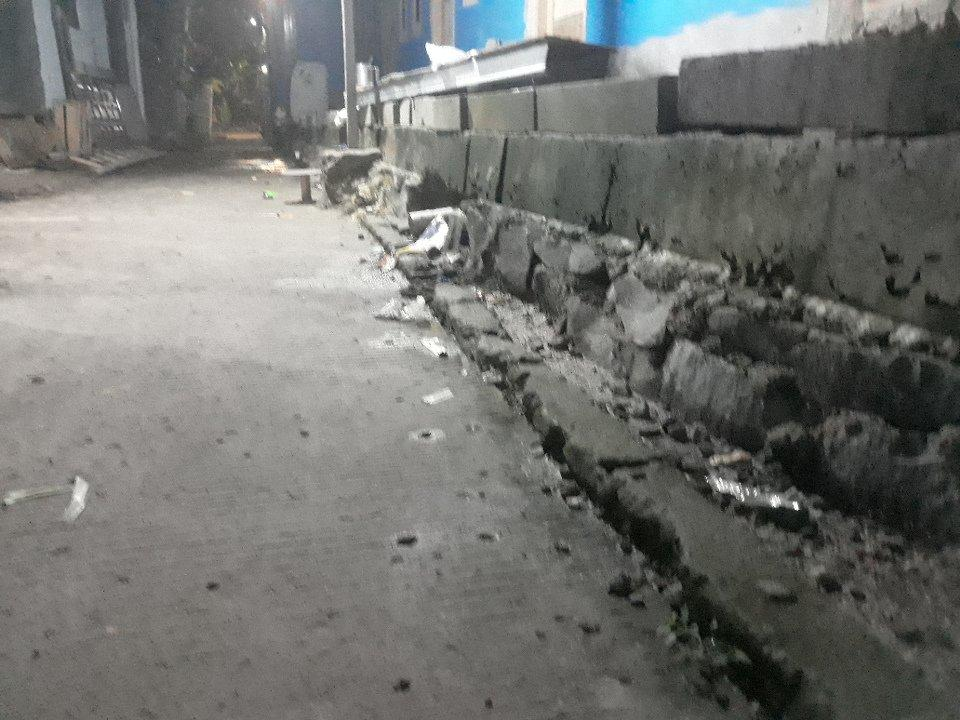

In [ ]:
dataset[1]["image"]

In [ ]:
embeddings_df = huggingface_img_embedding(
    df,
    modelname="facebook/dinov2-base",
    batched=True,
    batch_size=24,
)

df["img_embed"] = embeddings_df["embedding"]
df.head()

,report_id,number,date,month,year,image_path,description,location,category,dinas,dinas_clean,image,img_embed
0,JK2301010001,1,1,1,23,JK2301010001.jpg,tolong nyalakn lampu pju sering terjadi tawura...,KELURAHAN KALI BARU,Jalan,DINAS BINA MARGA,DINAS BINA MARGA,/kaggle/input/gemastik2024/photo/photo/JK23010...,"[-2.9664717, 1.0623682, 0.19622321, 1.4847742,..."
1,JK2301010002,2,1,1,23,JK2301010002.jpg,mohon di cek dan di tindak sesuai peraturan ap...,KELURAHAN ROROTAN,Gangguan Ketenteraman dan Ketertiban,"DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN","DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN",/kaggle/input/gemastik2024/photo/photo/JK23010...,"[-1.4262383, -0.18515484, 0.71059626, -1.10106..."
2,JK2301010003,3,1,1,23,JK2301010003.jpg,Selama ada nya plang segel masih berlanjut kar...,KELURAHAN ROROTAN,Gangguan Ketenteraman dan Ketertiban,"DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN","DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN",/kaggle/input/gemastik2024/photo/photo/JK23010...,"[-2.0935771, -1.8252734, 0.29245886, 1.7937984..."
3,JK2301010006,6,1,1,23,JK2301010006.jpg,tolong diperbaiki lampu jalan utama terimakasi...,KELURAHAN SEMANAN,Pekerja Penanganan Prasarana dan Sarana Umum K...,DINAS BINA MARGA,DINAS BINA MARGA,/kaggle/input/gemastik2024/photo/photo/JK23010...,"[-0.6245763, 1.4741216, 0.61297643, 1.661447, ..."
4,JK2301010007,7,1,1,23,JK2301010007.jpg,tolong diperbaiki lampu jalan utama terimakasi...,KELURAHAN SEMANAN,Pekerja Penanganan Prasarana dan Sarana Umum K...,DINAS BINA MARGA,DINAS BINA MARGA,/kaggle/input/gemastik2024/photo/photo/JK23010...,"[-1.4925165, 2.2810438, 0.3960876, 0.70647264,..."


In [ ]:
# save df["img_embed"].values with pkl
with open('dino_embed.pkl', 'wb') as f:
    pickle.dump(df["img_embed"].values, f)

In [ ]:
# Split the DataFrame into training and validation sets to 70% train, 15% validation, and 15% test
train_df, test_df = train_test_split(df, test_size=0.3, stratify=df['dinas_final'], random_state=42)
val_df, test_df = train_test_split(test_df, test_size=0.5, stratify=test_df['dinas_final'], random_state=42)

print(f"Train size: {train_df.shape}")
print(f"Validation size: {val_df.shape}")
print(f"Test size: {test_df.shape}")

Train size: (37719, 14)
Validation size: (8083, 14)
Test size: (8083, 14)


## Training

### DINOv2 only

#### DINOv2 Base

In [ ]:
train_df.reset_index(drop=True, inplace=True)
val_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

embed_feat = ["img_embed"]

train_pool = Pool(
    data=train_df[embed_feat].to_numpy(),
    label=train_df['dinas_final'].to_numpy(),
    embedding_features=embed_feat,
    feature_names=embed_feat
)

val_pool = Pool(
    data=val_df[embed_feat].to_numpy(),
    label=val_df['dinas_final'].to_numpy(),
    embedding_features=embed_feat,
    feature_names=embed_feat
)

In [ ]:
class_weights_dict = dict()
n, num_class = train_df.shape[0], len(train_df['dinas_final'].unique())
for label in train_df['dinas_final'].unique():
    n_l = train_df[train_df['dinas_final'] == label].shape[0]
    class_weights_dict[label] = n / (num_class * n_l)

class_weights_dict

{'DINAS BINA MARGA': 0.5688110749185668,
 'other': 1.3389776357827476,
 'KELURAHAN': 0.6716346153846153,
 'DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN': 3.942615239887112,
 'BADAN PEMBINAAN BADAN USAHA MILIK DAERAH': 4.267820773930754,
 'DINAS PERHUBUNGAN': 0.6402383134738772,
 'SATUAN POLISI PAMONG PRAJA': 0.5743456214882828,
 'DINAS SUMBER DAYA AIR': 3.199236641221374,
 'DINAS PERTAMANAN DAN HUTAN': 1.1078509119746234}

In [ ]:
cb_model = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='Accuracy',
    task_type="GPU",
    devices="0",
    verbose=100,
    random_state=42,
    class_weights = class_weights_dict,
    learning_rate=0.01
)

cb_model.fit(
    train_pool,
    eval_set=val_pool
)

0:	learn: 0.4785804	test: 0.5077133	best: 0.5077133 (0)	total: 21ms	remaining: 21s
100:	learn: 0.5536616	test: 0.5839789	best: 0.5842815 (99)	total: 1.14s	remaining: 10.1s
200:	learn: 0.5675630	test: 0.5956613	best: 0.5958251 (197)	total: 2.27s	remaining: 9.01s
300:	learn: 0.5739994	test: 0.6030202	best: 0.6030202 (300)	total: 3.38s	remaining: 7.86s
400:	learn: 0.5794252	test: 0.6032947	best: 0.6038284 (315)	total: 4.44s	remaining: 6.63s
500:	learn: 0.5825191	test: 0.6054772	best: 0.6054772 (500)	total: 5.46s	remaining: 5.44s
600:	learn: 0.5856877	test: 0.6071208	best: 0.6072946 (586)	total: 6.49s	remaining: 4.31s
700:	learn: 0.5883329	test: 0.6075363	best: 0.6085971 (681)	total: 7.55s	remaining: 3.22s
800:	learn: 0.5912156	test: 0.6079494	best: 0.6085971 (681)	total: 8.59s	remaining: 2.13s
900:	learn: 0.5940368	test: 0.6092805	best: 0.6095335 (894)	total: 9.62s	remaining: 1.06s
999:	learn: 0.5962687	test: 0.6089454	best: 0.6096220 (958)	total: 10.7s	remaining: 0us
bestTest = 0.6096220

In [ ]:
test_pred = cb_model.predict(test_df[embed_feat])
test_df['label'] = np.array(test_pred).reshape(-1)
test_df.head()

,report_id,number,date,month,year,image_path,description,location,category,dinas,dinas_clean,image,img_embed,dinas_final,label
0,JK2306180342,342,18,6,23,JK2306180342.jpg,"turunkan semua spanduk liar, merusak keindahan...",KELURAHAN KLENDER,"Keluhan Fasilitas Gedung Pemda (sekolah, kantor)",SATUAN POLISI PAMONG PRAJA,SATUAN POLISI PAMONG PRAJA,/kaggle/input/gemastik2024/photo/photo/JK23061...,"[1.1391969, 2.2461948, 1.9417709, -1.1657311, ...",SATUAN POLISI PAMONG PRAJA,SATUAN POLISI PAMONG PRAJA
1,JK2308260141,141,26,8,23,JK2308260141.jpg,segera diasphal dsdi patokan jln prof satrio n...,KELURAHAN KARET SEMANGGI,Jalan,UNIT PERALATAN DAN PERBEKALAN BINA MARGA,DINAS BINA MARGA,/kaggle/input/gemastik2024/photo/photo/JK23082...,"[-0.082434386, 0.3440839, -0.11563944, -0.4822...",DINAS BINA MARGA,DINAS BINA MARGA
2,JK2311250441,441,25,11,23,JK2311250441.jpg,Parkir liar di bahu jalan memakan hampir 2 laj...,KELURAHAN CIPINANG BESAR SELATAN,Parkir Liar,DINAS PERHUBUNGAN,DINAS PERHUBUNGAN,/kaggle/input/gemastik2024/photo/photo/JK23112...,"[-0.7417765, -0.68902934, 2.0540793, -1.297038...",DINAS PERHUBUNGAN,SATUAN POLISI PAMONG PRAJA
3,JK2304090106,106,9,4,23,JK2304090106.jpg,Ketika Suku Badan Kesatuan Bangsa dan politik ...,KELURAHAN CIBUBUR,Perizinan,SATUAN POLISI PAMONG PRAJA,SATUAN POLISI PAMONG PRAJA,/kaggle/input/gemastik2024/photo/photo/JK23040...,"[0.7830015, 0.3130233, -0.0045968373, 0.019434...",SATUAN POLISI PAMONG PRAJA,DINAS PERTAMANAN DAN HUTAN
4,JK2309010379,379,1,9,23,JK2309010379.jpg,tolong ini mobil motor di bahu jalan belum law...,KELURAHAN SRENGSENG SAWAH,Jalan,DINAS PERHUBUNGAN,DINAS PERHUBUNGAN,/kaggle/input/gemastik2024/photo/photo/JK23090...,"[0.46719706, 0.81567144, 1.5516601, -1.2278503...",DINAS PERHUBUNGAN,DINAS PERHUBUNGAN


Accuracy:  0.6195719411109737
Balanced Accuracy: 0.6081744373427077
Classification Report:
                                               precision    recall  f1-score   support

                             DINAS BINA MARGA       0.36      0.49      0.41       211
                                        other       0.71      0.62      0.66      1579
                                    KELURAHAN       0.63      0.85      0.72       228
DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN       0.62      0.74      0.67      1402
     BADAN PEMBINAAN BADAN USAHA MILIK DAERAH       0.66      0.69      0.68       811
                            DINAS PERHUBUNGAN       0.37      0.61      0.46       281
                   SATUAN POLISI PAMONG PRAJA       0.63      0.49      0.55      1337
                        DINAS SUMBER DAYA AIR       0.71      0.73      0.72      1564
                   DINAS PERTAMANAN DAN HUTAN       0.37      0.26      0.31       670

                                     

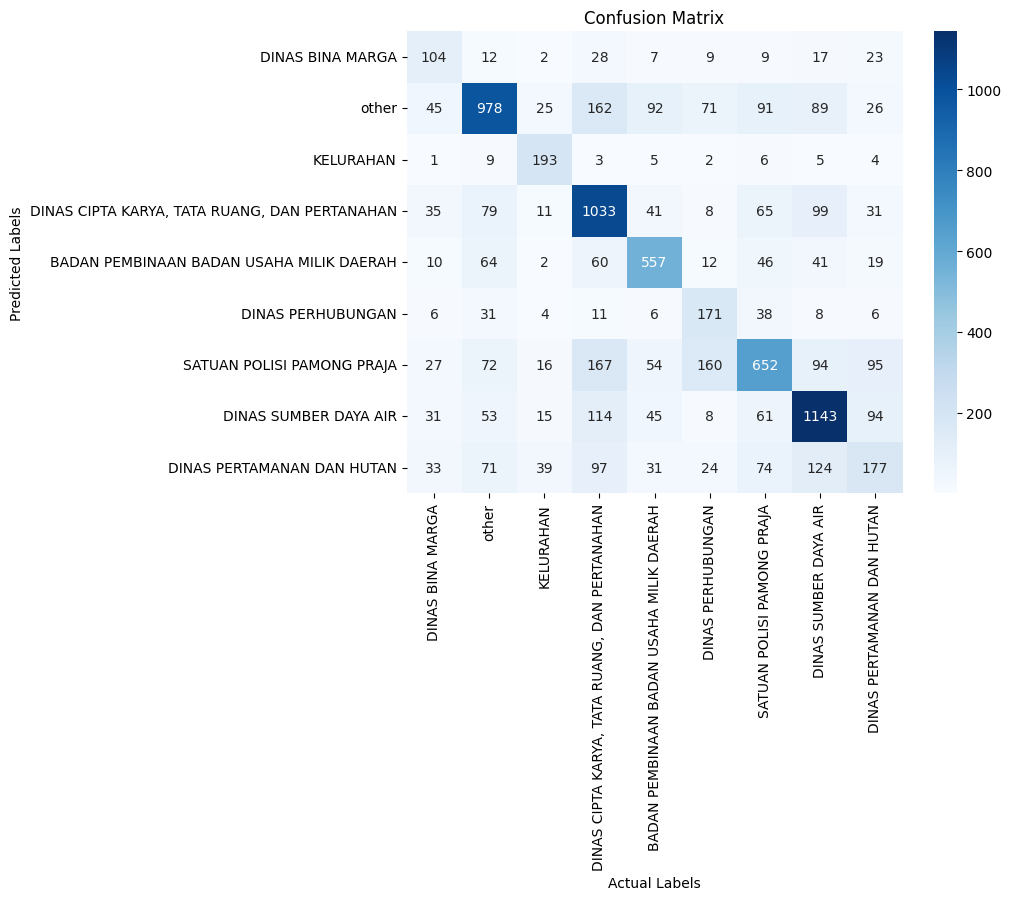

In [ ]:
evaluate_model(cb_model, test_df)

#### DINOv2 Large

In [ ]:
cb_model = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='Accuracy',
    task_type="GPU",
    devices="0",
    verbose=100,
    random_state=42,
    class_weights = class_weights_dict,
    learning_rate=0.01
)

cb_model.fit(
    train_pool,
    eval_set=val_pool
)

0:	learn: 0.4978958	test: 0.5232008	best: 0.5232008 (0)	total: 18.3ms	remaining: 18.2s
100:	learn: 0.5737714	test: 0.6060245	best: 0.6068441 (93)	total: 1.17s	remaining: 10.4s
200:	learn: 0.5841786	test: 0.6196798	best: 0.6203340 (192)	total: 2.18s	remaining: 8.65s
300:	learn: 0.5901888	test: 0.6228419	best: 0.6229198 (296)	total: 3.24s	remaining: 7.53s
400:	learn: 0.5959999	test: 0.6265562	best: 0.6265562 (399)	total: 4.29s	remaining: 6.4s
500:	learn: 0.5997039	test: 0.6291536	best: 0.6291536 (500)	total: 5.35s	remaining: 5.32s
600:	learn: 0.6029137	test: 0.6289541	best: 0.6296872 (588)	total: 6.4s	remaining: 4.25s
700:	learn: 0.6054583	test: 0.6317410	best: 0.6322605 (682)	total: 7.44s	remaining: 3.17s
800:	learn: 0.6089760	test: 0.6318219	best: 0.6323673 (754)	total: 8.48s	remaining: 2.11s
900:	learn: 0.6118754	test: 0.6309865	best: 0.6330182 (831)	total: 9.53s	remaining: 1.05s
999:	learn: 0.6138804	test: 0.6315330	best: 0.6330182 (831)	total: 10.6s	remaining: 0us
bestTest = 0.63301

In [ ]:
test_pred = cb_model.predict(test_df[embed_feat])
test_df['label'] = np.array(test_pred).reshape(-1)
test_df.head()

,report_id,number,date,month,year,image_path,description,location,category,dinas,dinas_clean,image,dinas_final,img_embed_flava,img_embed_flava_v1,text_embed,img_embed,label
0,JK2306180342,342,18,6,23,JK2306180342.jpg,"turunkan semua spanduk liar, merusak keindahan...",KELURAHAN KLENDER,"Keluhan Fasilitas Gedung Pemda (sekolah, kantor)",SATUAN POLISI PAMONG PRAJA,SATUAN POLISI PAMONG PRAJA,/kaggle/input/gemastik2024/photo/photo/JK23061...,SATUAN POLISI PAMONG PRAJA,"[-0.042070124, 0.05262886, -0.065062255, -0.00...","[-0.042070124, 0.05262886, -0.065062255, -0.00...","[0.06456372, 0.02033593, -0.071318015, 0.01529...","[1.6455362, -0.9255953, 0.817816, 0.6802739, 0...",SATUAN POLISI PAMONG PRAJA
1,JK2308260141,141,26,8,23,JK2308260141.jpg,segera diasphal dsdi patokan jln prof satrio n...,KELURAHAN KARET SEMANGGI,Jalan,UNIT PERALATAN DAN PERBEKALAN BINA MARGA,DINAS BINA MARGA,/kaggle/input/gemastik2024/photo/photo/JK23082...,DINAS BINA MARGA,"[-0.02845743, 0.024209492, -0.027055703, -0.07...","[-0.02845743, 0.024209492, -0.027055703, -0.07...","[0.023498751, 0.027393224, -0.045266606, -0.01...","[0.91373414, -1.7789384, -1.6952429, -0.565982...",DINAS BINA MARGA
2,JK2311250441,441,25,11,23,JK2311250441.jpg,Parkir liar di bahu jalan memakan hampir 2 laj...,KELURAHAN CIPINANG BESAR SELATAN,Parkir Liar,DINAS PERHUBUNGAN,DINAS PERHUBUNGAN,/kaggle/input/gemastik2024/photo/photo/JK23112...,DINAS PERHUBUNGAN,"[0.04832907, 0.019501302, -0.020758469, -0.035...","[0.04832907, 0.019501302, -0.020758469, -0.035...","[-0.009187295, -0.009120483, 0.012926119, -0.0...","[2.7343504, -2.3846152, 2.2076159, -0.08523672...",DINAS PERHUBUNGAN
3,JK2304090106,106,9,4,23,JK2304090106.jpg,Ketika Suku Badan Kesatuan Bangsa dan politik ...,KELURAHAN CIBUBUR,Perizinan,SATUAN POLISI PAMONG PRAJA,SATUAN POLISI PAMONG PRAJA,/kaggle/input/gemastik2024/photo/photo/JK23040...,SATUAN POLISI PAMONG PRAJA,"[-0.011295048, -0.0055511803, -0.028427957, -0...","[-0.011295048, -0.0055511803, -0.028427957, -0...","[0.0022210174, 0.0045210947, -0.02429384, -0.0...","[1.7590145, -0.9358065, -0.14855349, -0.039757...",SATUAN POLISI PAMONG PRAJA
4,JK2309010379,379,1,9,23,JK2309010379.jpg,tolong ini mobil motor di bahu jalan belum law...,KELURAHAN SRENGSENG SAWAH,Jalan,DINAS PERHUBUNGAN,DINAS PERHUBUNGAN,/kaggle/input/gemastik2024/photo/photo/JK23090...,DINAS PERHUBUNGAN,"[0.032454036, -0.07366714, -0.06683984, 0.0583...","[0.032454036, -0.07366714, -0.06683984, 0.0583...","[0.05521235, -0.032705072, -0.0032434952, -0.0...","[0.99790007, -1.2546221, -0.5877326, 0.4530511...",DINAS PERHUBUNGAN


Accuracy:  0.6386242731659038
Balanced Accuracy: 0.6420294207643533
Classification Report:
                                               precision    recall  f1-score   support

                             DINAS BINA MARGA       0.37      0.56      0.44       211
                                        other       0.74      0.63      0.68      1579
                                    KELURAHAN       0.64      0.89      0.74       228
DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN       0.62      0.77      0.69      1402
     BADAN PEMBINAAN BADAN USAHA MILIK DAERAH       0.69      0.75      0.72       811
                            DINAS PERHUBUNGAN       0.37      0.69      0.48       281
                   SATUAN POLISI PAMONG PRAJA       0.66      0.51      0.58      1337
                        DINAS SUMBER DAYA AIR       0.74      0.71      0.72      1564
                   DINAS PERTAMANAN DAN HUTAN       0.41      0.26      0.32       670

                                     

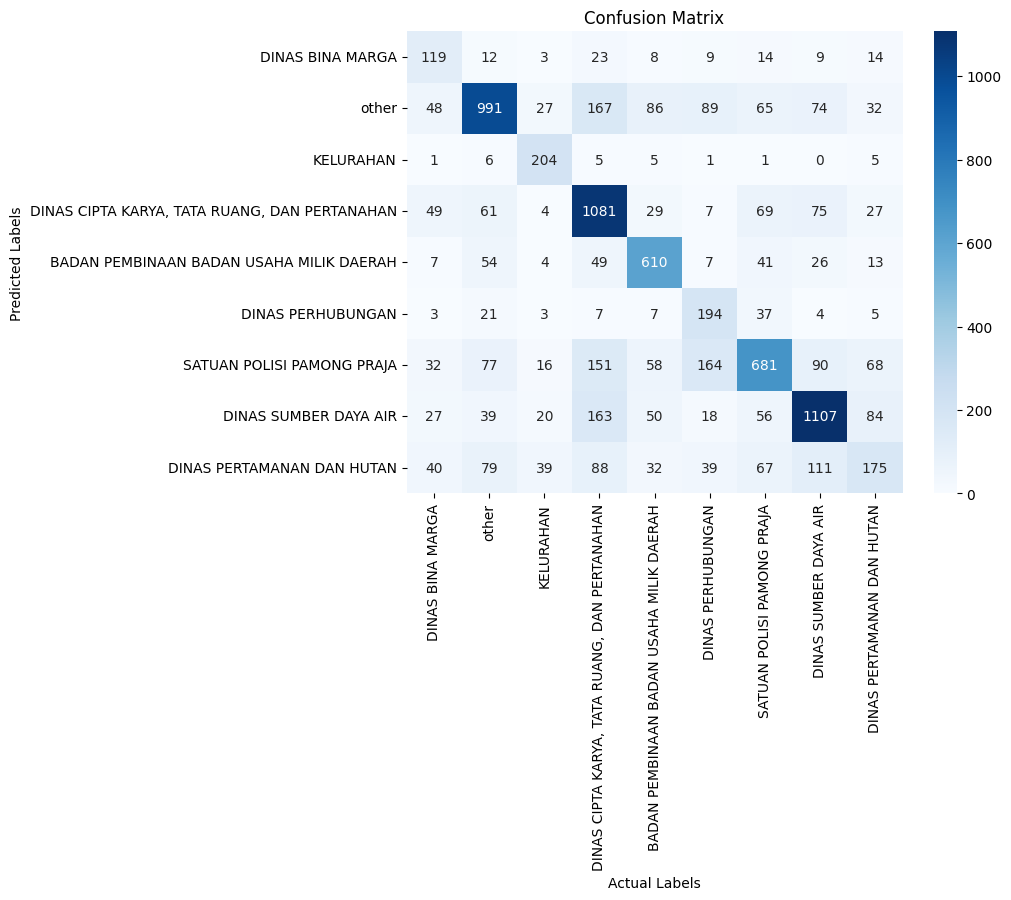

In [ ]:
evaluate_model(cb_model, test_df)

### DINOv2 + CatBoost Text Embedding

In [ ]:
train_df.reset_index(drop=True, inplace=True)
val_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

text_feat = ["description"]
embed_feat = ["img_embed"]

train_pool = Pool(
    data=train_df[text_feat + embed_feat].to_numpy(),
    label=train_df['dinas_final'].to_numpy(),
    text_features=text_feat,
    embedding_features=embed_feat,
    feature_names=text_feat+embed_feat
)

val_pool = Pool(
    data=val_df[text_feat + embed_feat].to_numpy(),
    label=val_df['dinas_final'].to_numpy(),
    text_features=text_feat,
    embedding_features=embed_feat,
    feature_names=text_feat+embed_feat
)

In [ ]:
class_weights_dict = dict()
n, num_class = train_df.shape[0], len(train_df['dinas_final'].unique())
for label in train_df['dinas_final'].unique():
    n_l = train_df[train_df['dinas_final'] == label].shape[0]
    class_weights_dict[label] = n / (num_class * n_l)

class_weights_dict

{'DINAS BINA MARGA': 0.5688110749185668,
 'other': 1.3389776357827476,
 'KELURAHAN': 0.6716346153846153,
 'DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN': 3.942615239887112,
 'BADAN PEMBINAAN BADAN USAHA MILIK DAERAH': 4.267820773930754,
 'DINAS PERHUBUNGAN': 0.6402383134738772,
 'SATUAN POLISI PAMONG PRAJA': 0.5743456214882828,
 'DINAS SUMBER DAYA AIR': 3.199236641221374,
 'DINAS PERTAMANAN DAN HUTAN': 1.1078509119746234}

In [ ]:
cb_model = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='Accuracy',
    task_type="GPU",
    devices="0",
    verbose=100,
    random_state=42,
    class_weights = class_weights_dict,
    learning_rate=0.01
)

cb_model.fit(
    train_pool,
    eval_set=val_pool
)

0:	learn: 0.6145485	test: 0.6306984	best: 0.6306984 (0)	total: 192ms	remaining: 3m 11s
100:	learn: 0.7130776	test: 0.7339566	best: 0.7340364 (99)	total: 1.8s	remaining: 16.1s
200:	learn: 0.7246817	test: 0.7457584	best: 0.7457584 (200)	total: 3.42s	remaining: 13.6s
300:	learn: 0.7338643	test: 0.7533873	best: 0.7533873 (299)	total: 5.05s	remaining: 11.7s
400:	learn: 0.7409537	test: 0.7583372	best: 0.7583372 (396)	total: 6.63s	remaining: 9.9s
500:	learn: 0.7459804	test: 0.7622750	best: 0.7623703 (493)	total: 8.12s	remaining: 8.09s
600:	learn: 0.7502026	test: 0.7672965	best: 0.7672965 (600)	total: 9.59s	remaining: 6.37s
700:	learn: 0.7540620	test: 0.7690884	best: 0.7691088 (662)	total: 11s	remaining: 4.7s
800:	learn: 0.7575629	test: 0.7713819	best: 0.7713819 (800)	total: 12.4s	remaining: 3.09s
900:	learn: 0.7604786	test: 0.7736656	best: 0.7736656 (899)	total: 13.8s	remaining: 1.52s
999:	learn: 0.7623022	test: 0.7758740	best: 0.7758740 (997)	total: 15.3s	remaining: 0us
bestTest = 0.77587400

In [ ]:
test_pred = cb_model.predict(test_df[text_feat + embed_feat])
test_df['label'] = np.array(test_pred).reshape(-1)
test_df.head()

,report_id,number,date,month,year,image_path,description,location,category,dinas,dinas_clean,image,img_embed,dinas_final,label
0,JK2306180342,342,18,6,23,JK2306180342.jpg,"turunkan semua spanduk liar, merusak keindahan...",KELURAHAN KLENDER,"Keluhan Fasilitas Gedung Pemda (sekolah, kantor)",SATUAN POLISI PAMONG PRAJA,SATUAN POLISI PAMONG PRAJA,/kaggle/input/gemastik2024/photo/photo/JK23061...,"[1.1391969, 2.2461948, 1.9417709, -1.1657311, ...",SATUAN POLISI PAMONG PRAJA,SATUAN POLISI PAMONG PRAJA
1,JK2308260141,141,26,8,23,JK2308260141.jpg,segera diasphal dsdi patokan jln prof satrio n...,KELURAHAN KARET SEMANGGI,Jalan,UNIT PERALATAN DAN PERBEKALAN BINA MARGA,DINAS BINA MARGA,/kaggle/input/gemastik2024/photo/photo/JK23082...,"[-0.082434386, 0.3440839, -0.11563944, -0.4822...",DINAS BINA MARGA,DINAS BINA MARGA
2,JK2311250441,441,25,11,23,JK2311250441.jpg,Parkir liar di bahu jalan memakan hampir 2 laj...,KELURAHAN CIPINANG BESAR SELATAN,Parkir Liar,DINAS PERHUBUNGAN,DINAS PERHUBUNGAN,/kaggle/input/gemastik2024/photo/photo/JK23112...,"[-0.7417765, -0.68902934, 2.0540793, -1.297038...",DINAS PERHUBUNGAN,DINAS PERHUBUNGAN
3,JK2304090106,106,9,4,23,JK2304090106.jpg,Ketika Suku Badan Kesatuan Bangsa dan politik ...,KELURAHAN CIBUBUR,Perizinan,SATUAN POLISI PAMONG PRAJA,SATUAN POLISI PAMONG PRAJA,/kaggle/input/gemastik2024/photo/photo/JK23040...,"[0.7830015, 0.3130233, -0.0045968373, 0.019434...",SATUAN POLISI PAMONG PRAJA,SATUAN POLISI PAMONG PRAJA
4,JK2309010379,379,1,9,23,JK2309010379.jpg,tolong ini mobil motor di bahu jalan belum law...,KELURAHAN SRENGSENG SAWAH,Jalan,DINAS PERHUBUNGAN,DINAS PERHUBUNGAN,/kaggle/input/gemastik2024/photo/photo/JK23090...,"[0.46719706, 0.81567144, 1.5516601, -1.2278503...",DINAS PERHUBUNGAN,DINAS PERHUBUNGAN


In [ ]:
test_df.head()

,report_id,number,date,month,year,image_path,description,location,category,dinas,dinas_clean,image,img_embed,dinas_final,label
0,JK2306180342,342,18,6,23,JK2306180342.jpg,"turunkan semua spanduk liar, merusak keindahan...",KELURAHAN KLENDER,"Keluhan Fasilitas Gedung Pemda (sekolah, kantor)",SATUAN POLISI PAMONG PRAJA,SATUAN POLISI PAMONG PRAJA,/kaggle/input/gemastik2024/photo/photo/JK23061...,"[1.1391969, 2.2461948, 1.9417709, -1.1657311, ...",SATUAN POLISI PAMONG PRAJA,SATUAN POLISI PAMONG PRAJA
1,JK2308260141,141,26,8,23,JK2308260141.jpg,segera diasphal dsdi patokan jln prof satrio n...,KELURAHAN KARET SEMANGGI,Jalan,UNIT PERALATAN DAN PERBEKALAN BINA MARGA,DINAS BINA MARGA,/kaggle/input/gemastik2024/photo/photo/JK23082...,"[-0.082434386, 0.3440839, -0.11563944, -0.4822...",DINAS BINA MARGA,DINAS BINA MARGA
2,JK2311250441,441,25,11,23,JK2311250441.jpg,Parkir liar di bahu jalan memakan hampir 2 laj...,KELURAHAN CIPINANG BESAR SELATAN,Parkir Liar,DINAS PERHUBUNGAN,DINAS PERHUBUNGAN,/kaggle/input/gemastik2024/photo/photo/JK23112...,"[-0.7417765, -0.68902934, 2.0540793, -1.297038...",DINAS PERHUBUNGAN,DINAS PERHUBUNGAN
3,JK2304090106,106,9,4,23,JK2304090106.jpg,Ketika Suku Badan Kesatuan Bangsa dan politik ...,KELURAHAN CIBUBUR,Perizinan,SATUAN POLISI PAMONG PRAJA,SATUAN POLISI PAMONG PRAJA,/kaggle/input/gemastik2024/photo/photo/JK23040...,"[0.7830015, 0.3130233, -0.0045968373, 0.019434...",SATUAN POLISI PAMONG PRAJA,SATUAN POLISI PAMONG PRAJA
4,JK2309010379,379,1,9,23,JK2309010379.jpg,tolong ini mobil motor di bahu jalan belum law...,KELURAHAN SRENGSENG SAWAH,Jalan,DINAS PERHUBUNGAN,DINAS PERHUBUNGAN,/kaggle/input/gemastik2024/photo/photo/JK23090...,"[0.46719706, 0.81567144, 1.5516601, -1.2278503...",DINAS PERHUBUNGAN,DINAS PERHUBUNGAN


Accuracy:  0.7664233576642335
Balanced Accuracy: 0.7774584169764872
Classification Report:
                                               precision    recall  f1-score   support

                             DINAS BINA MARGA       0.42      0.79      0.55       211
                                        other       0.88      0.82      0.85      1579
                                    KELURAHAN       0.80      0.96      0.87       228
DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN       0.78      0.85      0.82      1402
     BADAN PEMBINAAN BADAN USAHA MILIK DAERAH       0.88      0.89      0.89       811
                            DINAS PERHUBUNGAN       0.38      0.85      0.53       281
                   SATUAN POLISI PAMONG PRAJA       0.81      0.60      0.69      1337
                        DINAS SUMBER DAYA AIR       0.88      0.81      0.84      1564
                   DINAS PERTAMANAN DAN HUTAN       0.54      0.41      0.47       670

                                     

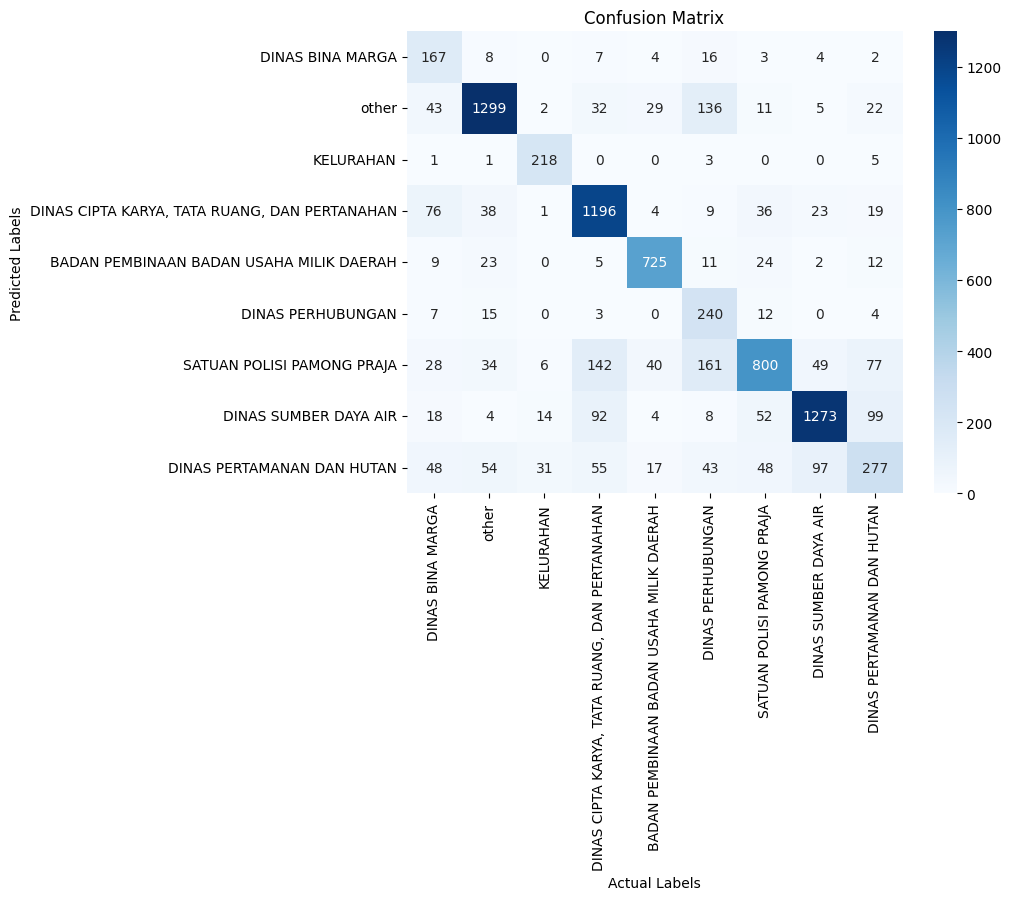

In [ ]:
evaluate_model(cb_model, test_df, 'dinas_final', 'label')

### Flava Multimodal

In [ ]:
embeddings_df = huggingface_multimodal_embedding(
    df,
    modelname="facebook/flava-full",
    batched=True,
    batch_size=8,
)

df["img_embed_flava"] = embeddings_df["embedding"]
df.head()

,report_id,number,date,month,year,image_path,description,location,category,dinas,dinas_clean,image,dinas_final,img_embed_flava
0,JK2301010001,1,1,1,23,JK2301010001.jpg,tolong nyalakn lampu pju sering terjadi tawura...,KELURAHAN KALI BARU,Jalan,DINAS BINA MARGA,DINAS BINA MARGA,/kaggle/input/gemastik2024/photo/photo/JK23010...,DINAS BINA MARGA,"[0.06608283, 0.048387114, -0.0041758493, 0.028..."
1,JK2301010002,2,1,1,23,JK2301010002.jpg,mohon di cek dan di tindak sesuai peraturan ap...,KELURAHAN ROROTAN,Gangguan Ketenteraman dan Ketertiban,"DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN","DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN",/kaggle/input/gemastik2024/photo/photo/JK23010...,"DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN","[-0.02130023, 0.0035175434, -0.071640246, 0.01..."
2,JK2301010003,3,1,1,23,JK2301010003.jpg,Selama ada nya plang segel masih berlanjut kar...,KELURAHAN ROROTAN,Gangguan Ketenteraman dan Ketertiban,"DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN","DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN",/kaggle/input/gemastik2024/photo/photo/JK23010...,"DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN","[-0.0833845, 0.04339636, -0.046543833, -0.0176..."
3,JK2301010006,6,1,1,23,JK2301010006.jpg,tolong diperbaiki lampu jalan utama terimakasi...,KELURAHAN SEMANAN,Pekerja Penanganan Prasarana dan Sarana Umum K...,DINAS BINA MARGA,DINAS BINA MARGA,/kaggle/input/gemastik2024/photo/photo/JK23010...,DINAS BINA MARGA,"[0.00654995, 0.010241772, -0.014649827, 0.1304..."
4,JK2301010007,7,1,1,23,JK2301010007.jpg,tolong diperbaiki lampu jalan utama terimakasi...,KELURAHAN SEMANAN,Pekerja Penanganan Prasarana dan Sarana Umum K...,DINAS BINA MARGA,DINAS BINA MARGA,/kaggle/input/gemastik2024/photo/photo/JK23010...,DINAS BINA MARGA,"[0.026130462, 0.04480181, -0.016486637, 0.1214..."


In [ ]:
# save df["img_embed"].values with pkl
with open('flava_full_embed_v2.pkl', 'wb') as f:
    pickle.dump(df["img_embed_flava"].values, f)

In [ ]:
with open('flava_full_embed.pkl', 'rb') as f:
    df["img_embed_flava_v1"] = pickle.load(f)

df.head()

,report_id,number,date,month,year,image_path,description,location,category,dinas,dinas_clean,image,dinas_final,img_embed_flava,img_embed_flava_v1
0,JK2301010001,1,1,1,23,JK2301010001.jpg,tolong nyalakn lampu pju sering terjadi tawura...,KELURAHAN KALI BARU,Jalan,DINAS BINA MARGA,DINAS BINA MARGA,/kaggle/input/gemastik2024/photo/photo/JK23010...,DINAS BINA MARGA,"[0.06608283, 0.048387114, -0.0041758493, 0.028...","[0.06608283, 0.048387114, -0.0041758493, 0.028..."
1,JK2301010002,2,1,1,23,JK2301010002.jpg,mohon di cek dan di tindak sesuai peraturan ap...,KELURAHAN ROROTAN,Gangguan Ketenteraman dan Ketertiban,"DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN","DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN",/kaggle/input/gemastik2024/photo/photo/JK23010...,"DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN","[-0.02130023, 0.0035175434, -0.071640246, 0.01...","[-0.02130023, 0.0035175434, -0.071640246, 0.01..."
2,JK2301010003,3,1,1,23,JK2301010003.jpg,Selama ada nya plang segel masih berlanjut kar...,KELURAHAN ROROTAN,Gangguan Ketenteraman dan Ketertiban,"DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN","DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN",/kaggle/input/gemastik2024/photo/photo/JK23010...,"DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN","[-0.0833845, 0.04339636, -0.046543833, -0.0176...","[-0.0833845, 0.04339636, -0.046543833, -0.0176..."
3,JK2301010006,6,1,1,23,JK2301010006.jpg,tolong diperbaiki lampu jalan utama terimakasi...,KELURAHAN SEMANAN,Pekerja Penanganan Prasarana dan Sarana Umum K...,DINAS BINA MARGA,DINAS BINA MARGA,/kaggle/input/gemastik2024/photo/photo/JK23010...,DINAS BINA MARGA,"[0.00654995, 0.010241772, -0.014649827, 0.1304...","[0.00654995, 0.010241772, -0.014649827, 0.1304..."
4,JK2301010007,7,1,1,23,JK2301010007.jpg,tolong diperbaiki lampu jalan utama terimakasi...,KELURAHAN SEMANAN,Pekerja Penanganan Prasarana dan Sarana Umum K...,DINAS BINA MARGA,DINAS BINA MARGA,/kaggle/input/gemastik2024/photo/photo/JK23010...,DINAS BINA MARGA,"[0.026130462, 0.04480181, -0.016486637, 0.1214...","[0.026130462, 0.04480181, -0.016486637, 0.1214..."


In [ ]:
# Split the DataFrame into training and validation sets to 70% train, 15% validation, and 15% test
train_df, test_df = train_test_split(df, test_size=0.3, stratify=df['dinas_final'], random_state=42)
val_df, test_df = train_test_split(test_df, test_size=0.5, stratify=test_df['dinas_final'], random_state=42)

print(f"Train size: {train_df.shape}")
print(f"Validation size: {val_df.shape}")
print(f"Test size: {test_df.shape}")

Train size: (37719, 15)
Validation size: (8083, 15)
Test size: (8083, 15)


In [ ]:
train_df.reset_index(drop=True, inplace=True)
val_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

embed_feat = ["img_embed_flava"]

train_pool = Pool(
    data=train_df[embed_feat].to_numpy(),
    label=train_df['dinas_final'].to_numpy(),
    embedding_features=embed_feat,
    feature_names=embed_feat
)

val_pool = Pool(
    data=val_df[embed_feat].to_numpy(),
    label=val_df['dinas_final'].to_numpy(),
    embedding_features=embed_feat,
    feature_names=embed_feat
)

In [ ]:
class_weights_dict = dict()
n, num_class = train_df.shape[0], len(train_df['dinas_final'].unique())
for label in train_df['dinas_final'].unique():
    n_l = train_df[train_df['dinas_final'] == label].shape[0]
    class_weights_dict[label] = n / (num_class * n_l)

class_weights_dict

{'DINAS BINA MARGA': 0.5688110749185668,
 'other': 1.3389776357827476,
 'KELURAHAN': 0.6716346153846153,
 'DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN': 3.942615239887112,
 'BADAN PEMBINAAN BADAN USAHA MILIK DAERAH': 4.267820773930754,
 'DINAS PERHUBUNGAN': 0.6402383134738772,
 'SATUAN POLISI PAMONG PRAJA': 0.5743456214882828,
 'DINAS SUMBER DAYA AIR': 3.199236641221374,
 'DINAS PERTAMANAN DAN HUTAN': 1.1078509119746234}

In [ ]:
cb_model = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='Accuracy',
    task_type="GPU",
    devices="0",
    verbose=100,
    random_state=42,
    class_weights = class_weights_dict,
    learning_rate=0.01
)

cb_model.fit(
    train_pool,
    eval_set=val_pool
)

0:	learn: 0.4786684	test: 0.5113181	best: 0.5113181 (0)	total: 20.7ms	remaining: 20.6s
100:	learn: 0.5769070	test: 0.6140955	best: 0.6145752 (90)	total: 1.23s	remaining: 10.9s
200:	learn: 0.5963058	test: 0.6313070	best: 0.6319623 (190)	total: 2.27s	remaining: 9.02s
300:	learn: 0.6092056	test: 0.6400818	best: 0.6418353 (278)	total: 3.31s	remaining: 7.7s
400:	learn: 0.6152909	test: 0.6435128	best: 0.6445545 (366)	total: 4.36s	remaining: 6.51s
500:	learn: 0.6201106	test: 0.6457898	best: 0.6461012 (493)	total: 5.42s	remaining: 5.4s
600:	learn: 0.6234001	test: 0.6481016	best: 0.6481016 (599)	total: 6.48s	remaining: 4.3s
700:	learn: 0.6270614	test: 0.6484188	best: 0.6490821 (674)	total: 7.53s	remaining: 3.21s
800:	learn: 0.6291972	test: 0.6481449	best: 0.6490821 (674)	total: 8.58s	remaining: 2.13s
900:	learn: 0.6317109	test: 0.6494985	best: 0.6497477 (893)	total: 9.63s	remaining: 1.06s
999:	learn: 0.6339119	test: 0.6490869	best: 0.6501404 (913)	total: 10.7s	remaining: 0us
bestTest = 0.650140

In [ ]:
test_pred = cb_model.predict(test_df[embed_feat])
test_df['label'] = np.array(test_pred).reshape(-1)
test_df.head()

,report_id,number,date,month,year,image_path,description,location,category,dinas,dinas_clean,image,dinas_final,img_embed_flava,img_embed_flava_v1,label
0,JK2306180342,342,18,6,23,JK2306180342.jpg,"turunkan semua spanduk liar, merusak keindahan...",KELURAHAN KLENDER,"Keluhan Fasilitas Gedung Pemda (sekolah, kantor)",SATUAN POLISI PAMONG PRAJA,SATUAN POLISI PAMONG PRAJA,/kaggle/input/gemastik2024/photo/photo/JK23061...,SATUAN POLISI PAMONG PRAJA,"[-0.042070124, 0.05262886, -0.065062255, -0.00...","[-0.042070124, 0.05262886, -0.065062255, -0.00...",SATUAN POLISI PAMONG PRAJA
1,JK2308260141,141,26,8,23,JK2308260141.jpg,segera diasphal dsdi patokan jln prof satrio n...,KELURAHAN KARET SEMANGGI,Jalan,UNIT PERALATAN DAN PERBEKALAN BINA MARGA,DINAS BINA MARGA,/kaggle/input/gemastik2024/photo/photo/JK23082...,DINAS BINA MARGA,"[-0.02845743, 0.024209492, -0.027055703, -0.07...","[-0.02845743, 0.024209492, -0.027055703, -0.07...",DINAS BINA MARGA
2,JK2311250441,441,25,11,23,JK2311250441.jpg,Parkir liar di bahu jalan memakan hampir 2 laj...,KELURAHAN CIPINANG BESAR SELATAN,Parkir Liar,DINAS PERHUBUNGAN,DINAS PERHUBUNGAN,/kaggle/input/gemastik2024/photo/photo/JK23112...,DINAS PERHUBUNGAN,"[0.04832907, 0.019501302, -0.020758469, -0.035...","[0.04832907, 0.019501302, -0.020758469, -0.035...",DINAS PERHUBUNGAN
3,JK2304090106,106,9,4,23,JK2304090106.jpg,Ketika Suku Badan Kesatuan Bangsa dan politik ...,KELURAHAN CIBUBUR,Perizinan,SATUAN POLISI PAMONG PRAJA,SATUAN POLISI PAMONG PRAJA,/kaggle/input/gemastik2024/photo/photo/JK23040...,SATUAN POLISI PAMONG PRAJA,"[-0.011295048, -0.0055511803, -0.028427957, -0...","[-0.011295048, -0.0055511803, -0.028427957, -0...",SATUAN POLISI PAMONG PRAJA
4,JK2309010379,379,1,9,23,JK2309010379.jpg,tolong ini mobil motor di bahu jalan belum law...,KELURAHAN SRENGSENG SAWAH,Jalan,DINAS PERHUBUNGAN,DINAS PERHUBUNGAN,/kaggle/input/gemastik2024/photo/photo/JK23090...,DINAS PERHUBUNGAN,"[0.032454036, -0.07366714, -0.06683984, 0.0583...","[0.032454036, -0.07366714, -0.06683984, 0.0583...",DINAS PERHUBUNGAN


Accuracy:  0.6436966472844241
Balanced Accuracy: 0.6583994672998785
Classification Report:
                                               precision    recall  f1-score   support

                             DINAS BINA MARGA       0.33      0.63      0.44       211
                                        other       0.77      0.64      0.70      1579
                                    KELURAHAN       0.62      0.90      0.73       228
DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN       0.67      0.74      0.70      1402
     BADAN PEMBINAAN BADAN USAHA MILIK DAERAH       0.75      0.82      0.78       811
                            DINAS PERHUBUNGAN       0.23      0.77      0.36       281
                   SATUAN POLISI PAMONG PRAJA       0.67      0.51      0.58      1337
                        DINAS SUMBER DAYA AIR       0.82      0.72      0.77      1564
                   DINAS PERTAMANAN DAN HUTAN       0.46      0.21      0.29       670

                                     

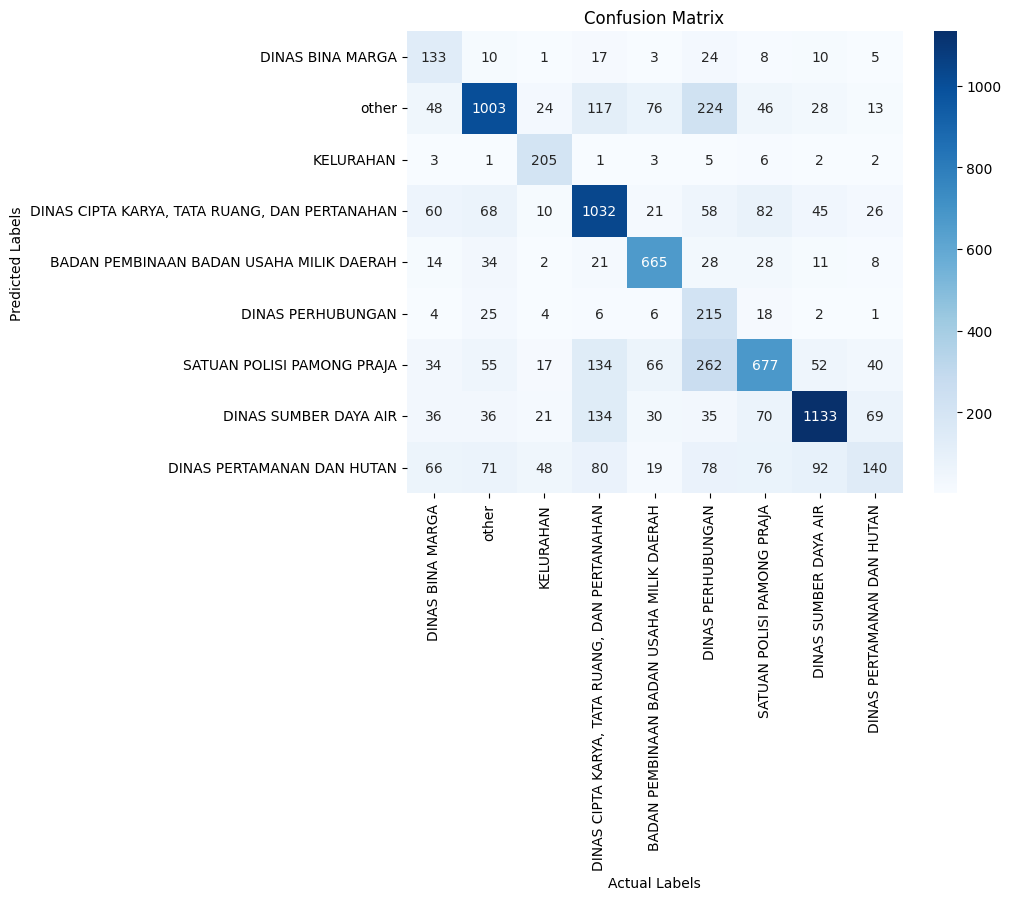

In [ ]:
evaluate_model(cb_model, test_df, 'dinas_final', 'label')

### CatBoost Text Embedding

In [ ]:
# Split the DataFrame into training and validation sets to 70% train, 15% validation, and 15% test
train_df, test_df = train_test_split(df, test_size=0.3, stratify=df['dinas_final'], random_state=42)
val_df, test_df = train_test_split(test_df, test_size=0.5, stratify=test_df['dinas_final'], random_state=42)

print(f"Train size: {train_df.shape}")
print(f"Validation size: {val_df.shape}")
print(f"Test size: {test_df.shape}")

Train size: (37719, 16)
Validation size: (8083, 16)
Test size: (8083, 16)


In [ ]:
train_df.reset_index(drop=True, inplace=True)
val_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

text_feat = ["description"]
feature_names = text_feat

train_pool = Pool(
    data=train_df[feature_names].to_numpy(),
    label=train_df['dinas_final'].to_numpy(),
    text_features=text_feat,
    feature_names=feature_names
)

val_pool = Pool(
    data=val_df[feature_names].to_numpy(),
    label=val_df['dinas_final'].to_numpy(),
    text_features=text_feat,
    feature_names=feature_names
)

In [ ]:
class_weights_dict = dict()
n, num_class = train_df.shape[0], len(train_df['dinas_final'].unique())
for label in train_df['dinas_final'].unique():
    n_l = train_df[train_df['dinas_final'] == label].shape[0]
    class_weights_dict[label] = n / (num_class * n_l)

class_weights_dict

{'DINAS BINA MARGA': 0.5688110749185668,
 'other': 1.3389776357827476,
 'KELURAHAN': 0.6716346153846153,
 'DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN': 3.942615239887112,
 'BADAN PEMBINAAN BADAN USAHA MILIK DAERAH': 4.267820773930754,
 'DINAS PERHUBUNGAN': 0.6402383134738772,
 'SATUAN POLISI PAMONG PRAJA': 0.5743456214882828,
 'DINAS SUMBER DAYA AIR': 3.199236641221374,
 'DINAS PERTAMANAN DAN HUTAN': 1.1078509119746234}

In [ ]:
cb_model = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='Accuracy',
    task_type="GPU",
    devices="0",
    verbose=100,
    random_state=42,
    class_weights = class_weights_dict,
    learning_rate=0.01
)

cb_model.fit(
    train_pool,
    eval_set=val_pool
)

0:	learn: 0.6145485	test: 0.6306984	best: 0.6306984 (0)	total: 29.9ms	remaining: 29.9s
100:	learn: 0.7109516	test: 0.7319236	best: 0.7326655 (99)	total: 1.64s	remaining: 14.6s
200:	learn: 0.7151581	test: 0.7353605	best: 0.7357661 (188)	total: 3.28s	remaining: 13s
300:	learn: 0.7187684	test: 0.7366611	best: 0.7377332 (249)	total: 4.84s	remaining: 11.2s
400:	learn: 0.7240749	test: 0.7401544	best: 0.7404032 (393)	total: 6.35s	remaining: 9.49s
500:	learn: 0.7270165	test: 0.7420683	best: 0.7420683 (497)	total: 7.84s	remaining: 7.81s
600:	learn: 0.7300891	test: 0.7448418	best: 0.7452458 (588)	total: 9.3s	remaining: 6.17s
700:	learn: 0.7326202	test: 0.7482950	best: 0.7482950 (694)	total: 10.7s	remaining: 4.57s
800:	learn: 0.7348484	test: 0.7496274	best: 0.7496274 (797)	total: 12.2s	remaining: 3.03s
900:	learn: 0.7362890	test: 0.7500408	best: 0.7502064 (897)	total: 13.8s	remaining: 1.51s
999:	learn: 0.7377139	test: 0.7503153	best: 0.7507192 (979)	total: 15.2s	remaining: 0us
bestTest = 0.750719

In [ ]:
test_pred = cb_model.predict(test_df[feature_names])
test_df['label'] = np.array(test_pred).reshape(-1)
test_df.head()

,report_id,number,date,month,year,image_path,description,location,category,dinas,dinas_clean,image,dinas_final,img_embed_flava,img_embed_flava_v1,text_embed,label
0,JK2306180342,342,18,6,23,JK2306180342.jpg,"turunkan semua spanduk liar, merusak keindahan...",KELURAHAN KLENDER,"Keluhan Fasilitas Gedung Pemda (sekolah, kantor)",SATUAN POLISI PAMONG PRAJA,SATUAN POLISI PAMONG PRAJA,/kaggle/input/gemastik2024/photo/photo/JK23061...,SATUAN POLISI PAMONG PRAJA,"[-0.042070124, 0.05262886, -0.065062255, -0.00...","[-0.042070124, 0.05262886, -0.065062255, -0.00...","[0.06456372, 0.02033593, -0.071318015, 0.01529...",SATUAN POLISI PAMONG PRAJA
1,JK2308260141,141,26,8,23,JK2308260141.jpg,segera diasphal dsdi patokan jln prof satrio n...,KELURAHAN KARET SEMANGGI,Jalan,UNIT PERALATAN DAN PERBEKALAN BINA MARGA,DINAS BINA MARGA,/kaggle/input/gemastik2024/photo/photo/JK23082...,DINAS BINA MARGA,"[-0.02845743, 0.024209492, -0.027055703, -0.07...","[-0.02845743, 0.024209492, -0.027055703, -0.07...","[0.023498751, 0.027393224, -0.045266606, -0.01...",DINAS BINA MARGA
2,JK2311250441,441,25,11,23,JK2311250441.jpg,Parkir liar di bahu jalan memakan hampir 2 laj...,KELURAHAN CIPINANG BESAR SELATAN,Parkir Liar,DINAS PERHUBUNGAN,DINAS PERHUBUNGAN,/kaggle/input/gemastik2024/photo/photo/JK23112...,DINAS PERHUBUNGAN,"[0.04832907, 0.019501302, -0.020758469, -0.035...","[0.04832907, 0.019501302, -0.020758469, -0.035...","[-0.009187295, -0.009120483, 0.012926119, -0.0...",DINAS PERHUBUNGAN
3,JK2304090106,106,9,4,23,JK2304090106.jpg,Ketika Suku Badan Kesatuan Bangsa dan politik ...,KELURAHAN CIBUBUR,Perizinan,SATUAN POLISI PAMONG PRAJA,SATUAN POLISI PAMONG PRAJA,/kaggle/input/gemastik2024/photo/photo/JK23040...,SATUAN POLISI PAMONG PRAJA,"[-0.011295048, -0.0055511803, -0.028427957, -0...","[-0.011295048, -0.0055511803, -0.028427957, -0...","[0.0022210174, 0.0045210947, -0.02429384, -0.0...",SATUAN POLISI PAMONG PRAJA
4,JK2309010379,379,1,9,23,JK2309010379.jpg,tolong ini mobil motor di bahu jalan belum law...,KELURAHAN SRENGSENG SAWAH,Jalan,DINAS PERHUBUNGAN,DINAS PERHUBUNGAN,/kaggle/input/gemastik2024/photo/photo/JK23090...,DINAS PERHUBUNGAN,"[0.032454036, -0.07366714, -0.06683984, 0.0583...","[0.032454036, -0.07366714, -0.06683984, 0.0583...","[0.05521235, -0.032705072, -0.0032434952, -0.0...",DINAS PERHUBUNGAN


Accuracy:  0.7397006062105654
Balanced Accuracy: 0.7494002831389212
Classification Report:
                                               precision    recall  f1-score   support

                             DINAS BINA MARGA       0.36      0.79      0.49       211
                                        other       0.88      0.79      0.83      1579
                                    KELURAHAN       0.78      0.92      0.85       228
DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN       0.76      0.83      0.80      1402
     BADAN PEMBINAAN BADAN USAHA MILIK DAERAH       0.88      0.89      0.89       811
                            DINAS PERHUBUNGAN       0.31      0.80      0.45       281
                   SATUAN POLISI PAMONG PRAJA       0.80      0.56      0.66      1337
                        DINAS SUMBER DAYA AIR       0.86      0.80      0.83      1564
                   DINAS PERTAMANAN DAN HUTAN       0.51      0.36      0.42       670

                                     

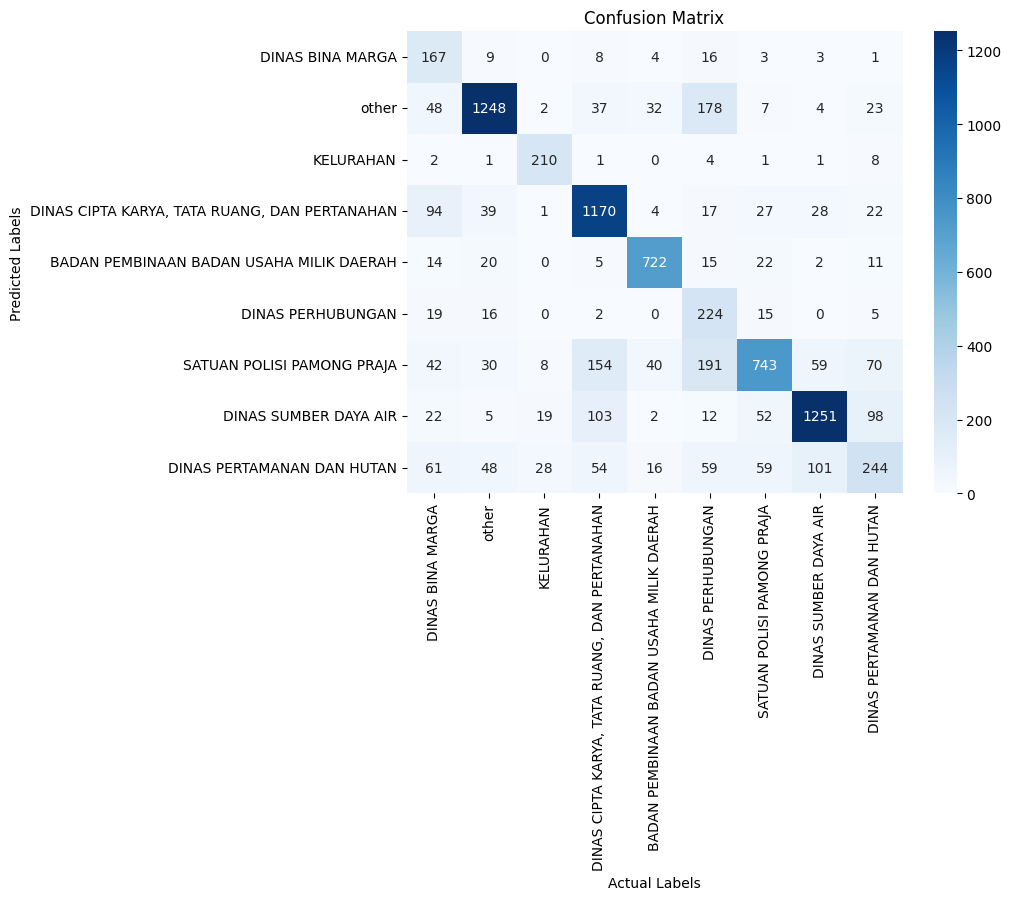

In [ ]:
evaluate_model(cb_model, test_df, 'dinas_final', 'label')

### Cendol Text Model

In [ ]:
embeddings_df = huggingface_text_embedding(
    df,
    modelname="indonlp/cendol-mt5-base-inst",
    batched=True,
    batch_size=24,
)

df["text_embed"] = embeddings_df["embedding"]
df.head()

In [ ]:
with open(f'{DATA_DIR}/cendol-mt5-large-inst.pkl', 'rb') as f:
    df["text_embed"] = pickle.load(f).text_embed

df.head()

,report_id,number,date,month,year,image_path,description,location,category,dinas,dinas_clean,image,dinas_final,img_embed_flava,img_embed_flava_v1,text_embed
0,JK2301010001,1,1,1,23,JK2301010001.jpg,tolong nyalakn lampu pju sering terjadi tawura...,KELURAHAN KALI BARU,Jalan,DINAS BINA MARGA,DINAS BINA MARGA,/kaggle/input/gemastik2024/photo/photo/JK23010...,DINAS BINA MARGA,"[0.06608283, 0.048387114, -0.0041758493, 0.028...","[0.06608283, 0.048387114, -0.0041758493, 0.028...","[0.09056297, 0.05615388, -0.119688824, 0.04499..."
1,JK2301010002,2,1,1,23,JK2301010002.jpg,mohon di cek dan di tindak sesuai peraturan ap...,KELURAHAN ROROTAN,Gangguan Ketenteraman dan Ketertiban,"DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN","DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN",/kaggle/input/gemastik2024/photo/photo/JK23010...,"DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN","[-0.02130023, 0.0035175434, -0.071640246, 0.01...","[-0.02130023, 0.0035175434, -0.071640246, 0.01...","[0.13310267, 0.070461385, -0.040767223, 0.0144..."
2,JK2301010003,3,1,1,23,JK2301010003.jpg,Selama ada nya plang segel masih berlanjut kar...,KELURAHAN ROROTAN,Gangguan Ketenteraman dan Ketertiban,"DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN","DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN",/kaggle/input/gemastik2024/photo/photo/JK23010...,"DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN","[-0.0833845, 0.04339636, -0.046543833, -0.0176...","[-0.0833845, 0.04339636, -0.046543833, -0.0176...","[-0.009591767, 0.007920389, -0.054674786, -0.0..."
3,JK2301010006,6,1,1,23,JK2301010006.jpg,tolong diperbaiki lampu jalan utama terimakasi...,KELURAHAN SEMANAN,Pekerja Penanganan Prasarana dan Sarana Umum K...,DINAS BINA MARGA,DINAS BINA MARGA,/kaggle/input/gemastik2024/photo/photo/JK23010...,DINAS BINA MARGA,"[0.00654995, 0.010241772, -0.014649827, 0.1304...","[0.00654995, 0.010241772, -0.014649827, 0.1304...","[0.06634824, 0.09351404, -0.064733766, 0.00200..."
4,JK2301010007,7,1,1,23,JK2301010007.jpg,tolong diperbaiki lampu jalan utama terimakasi...,KELURAHAN SEMANAN,Pekerja Penanganan Prasarana dan Sarana Umum K...,DINAS BINA MARGA,DINAS BINA MARGA,/kaggle/input/gemastik2024/photo/photo/JK23010...,DINAS BINA MARGA,"[0.026130462, 0.04480181, -0.016486637, 0.1214...","[0.026130462, 0.04480181, -0.016486637, 0.1214...","[0.07893172, 0.08947854, -0.050831888, 0.00938..."


In [ ]:
# Split the DataFrame into training and validation sets to 70% train, 15% validation, and 15% test
train_df, test_df = train_test_split(df, test_size=0.3, stratify=df['dinas_final'], random_state=42)
val_df, test_df = train_test_split(test_df, test_size=0.5, stratify=test_df['dinas_final'], random_state=42)

print(f"Train size: {train_df.shape}")
print(f"Validation size: {val_df.shape}")
print(f"Test size: {test_df.shape}")

Train size: (37719, 16)
Validation size: (8083, 16)
Test size: (8083, 16)


In [ ]:
train_df.reset_index(drop=True, inplace=True)
val_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

embed_feat = ["text_embed"]
feature_names = embed_feat

train_pool = Pool(
    data=train_df[embed_feat].to_numpy(),
    label=train_df['dinas_final'].to_numpy(),
    embedding_features=embed_feat,
    feature_names=embed_feat
)

val_pool = Pool(
    data=val_df[embed_feat].to_numpy(),
    label=val_df['dinas_final'].to_numpy(),
    embedding_features=embed_feat,
    feature_names=embed_feat
)

In [ ]:
class_weights_dict = dict()
n, num_class = train_df.shape[0], len(train_df['dinas_final'].unique())
for label in train_df['dinas_final'].unique():
    n_l = train_df[train_df['dinas_final'] == label].shape[0]
    class_weights_dict[label] = n / (num_class * n_l)

class_weights_dict

{'DINAS BINA MARGA': 0.5688110749185668,
 'other': 1.3389776357827476,
 'KELURAHAN': 0.6716346153846153,
 'DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN': 3.942615239887112,
 'BADAN PEMBINAAN BADAN USAHA MILIK DAERAH': 4.267820773930754,
 'DINAS PERHUBUNGAN': 0.6402383134738772,
 'SATUAN POLISI PAMONG PRAJA': 0.5743456214882828,
 'DINAS SUMBER DAYA AIR': 3.199236641221374,
 'DINAS PERTAMANAN DAN HUTAN': 1.1078509119746234}

In [ ]:
cb_model = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='Accuracy',
    task_type="GPU",
    devices="0",
    verbose=100,
    random_state=42,
    class_weights = class_weights_dict,
    learning_rate=0.01
)

cb_model.fit(
    train_pool,
    eval_set=val_pool
)

0:	learn: 0.4703326	test: 0.5199238	best: 0.5199238 (0)	total: 22.2ms	remaining: 22.2s
100:	learn: 0.5560359	test: 0.6071633	best: 0.6080079 (98)	total: 1.4s	remaining: 12.4s
200:	learn: 0.5787753	test: 0.6232779	best: 0.6235060 (198)	total: 2.48s	remaining: 9.84s
300:	learn: 0.5948450	test: 0.6357602	best: 0.6357602 (300)	total: 3.54s	remaining: 8.23s
400:	learn: 0.6041297	test: 0.6415387	best: 0.6417044 (399)	total: 4.61s	remaining: 6.89s
500:	learn: 0.6117764	test: 0.6429280	best: 0.6438629 (475)	total: 5.68s	remaining: 5.66s
600:	learn: 0.6200061	test: 0.6445990	best: 0.6453134 (592)	total: 6.75s	remaining: 4.48s
700:	learn: 0.6252739	test: 0.6456052	best: 0.6456052 (700)	total: 7.79s	remaining: 3.32s
800:	learn: 0.6306760	test: 0.6463616	best: 0.6463616 (791)	total: 8.88s	remaining: 2.21s
900:	learn: 0.6341994	test: 0.6469218	best: 0.6471041 (855)	total: 9.94s	remaining: 1.09s
999:	learn: 0.6380582	test: 0.6476602	best: 0.6478259 (992)	total: 11s	remaining: 0us
bestTest = 0.647825

In [ ]:
test_pred = cb_model.predict(test_df[feature_names])
test_df['label'] = np.array(test_pred).reshape(-1)
test_df.head()

,report_id,number,date,month,year,image_path,description,location,category,dinas,dinas_clean,image,dinas_final,img_embed_flava,img_embed_flava_v1,text_embed,label
0,JK2306180342,342,18,6,23,JK2306180342.jpg,"turunkan semua spanduk liar, merusak keindahan...",KELURAHAN KLENDER,"Keluhan Fasilitas Gedung Pemda (sekolah, kantor)",SATUAN POLISI PAMONG PRAJA,SATUAN POLISI PAMONG PRAJA,/kaggle/input/gemastik2024/photo/photo/JK23061...,SATUAN POLISI PAMONG PRAJA,"[-0.042070124, 0.05262886, -0.065062255, -0.00...","[-0.042070124, 0.05262886, -0.065062255, -0.00...","[0.06456372, 0.02033593, -0.071318015, 0.01529...",SATUAN POLISI PAMONG PRAJA
1,JK2308260141,141,26,8,23,JK2308260141.jpg,segera diasphal dsdi patokan jln prof satrio n...,KELURAHAN KARET SEMANGGI,Jalan,UNIT PERALATAN DAN PERBEKALAN BINA MARGA,DINAS BINA MARGA,/kaggle/input/gemastik2024/photo/photo/JK23082...,DINAS BINA MARGA,"[-0.02845743, 0.024209492, -0.027055703, -0.07...","[-0.02845743, 0.024209492, -0.027055703, -0.07...","[0.023498751, 0.027393224, -0.045266606, -0.01...",DINAS BINA MARGA
2,JK2311250441,441,25,11,23,JK2311250441.jpg,Parkir liar di bahu jalan memakan hampir 2 laj...,KELURAHAN CIPINANG BESAR SELATAN,Parkir Liar,DINAS PERHUBUNGAN,DINAS PERHUBUNGAN,/kaggle/input/gemastik2024/photo/photo/JK23112...,DINAS PERHUBUNGAN,"[0.04832907, 0.019501302, -0.020758469, -0.035...","[0.04832907, 0.019501302, -0.020758469, -0.035...","[-0.009187295, -0.009120483, 0.012926119, -0.0...",DINAS PERHUBUNGAN
3,JK2304090106,106,9,4,23,JK2304090106.jpg,Ketika Suku Badan Kesatuan Bangsa dan politik ...,KELURAHAN CIBUBUR,Perizinan,SATUAN POLISI PAMONG PRAJA,SATUAN POLISI PAMONG PRAJA,/kaggle/input/gemastik2024/photo/photo/JK23040...,SATUAN POLISI PAMONG PRAJA,"[-0.011295048, -0.0055511803, -0.028427957, -0...","[-0.011295048, -0.0055511803, -0.028427957, -0...","[0.0022210174, 0.0045210947, -0.02429384, -0.0...",SATUAN POLISI PAMONG PRAJA
4,JK2309010379,379,1,9,23,JK2309010379.jpg,tolong ini mobil motor di bahu jalan belum law...,KELURAHAN SRENGSENG SAWAH,Jalan,DINAS PERHUBUNGAN,DINAS PERHUBUNGAN,/kaggle/input/gemastik2024/photo/photo/JK23090...,DINAS PERHUBUNGAN,"[0.032454036, -0.07366714, -0.06683984, 0.0583...","[0.032454036, -0.07366714, -0.06683984, 0.0583...","[0.05521235, -0.032705072, -0.0032434952, -0.0...",DINAS PERHUBUNGAN


Accuracy:  0.6773475194853396
Balanced Accuracy: 0.6563735903593815
Classification Report:
                                               precision    recall  f1-score   support

                             DINAS BINA MARGA       0.31      0.60      0.41       211
                                        other       0.78      0.74      0.76      1579
                                    KELURAHAN       0.45      0.95      0.61       228
DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN       0.70      0.73      0.72      1402
     BADAN PEMBINAAN BADAN USAHA MILIK DAERAH       0.78      0.86      0.82       811
                            DINAS PERHUBUNGAN       0.32      0.44      0.37       281
                   SATUAN POLISI PAMONG PRAJA       0.73      0.56      0.64      1337
                        DINAS SUMBER DAYA AIR       0.83      0.76      0.79      1564
                   DINAS PERTAMANAN DAN HUTAN       0.36      0.27      0.31       670

                                     

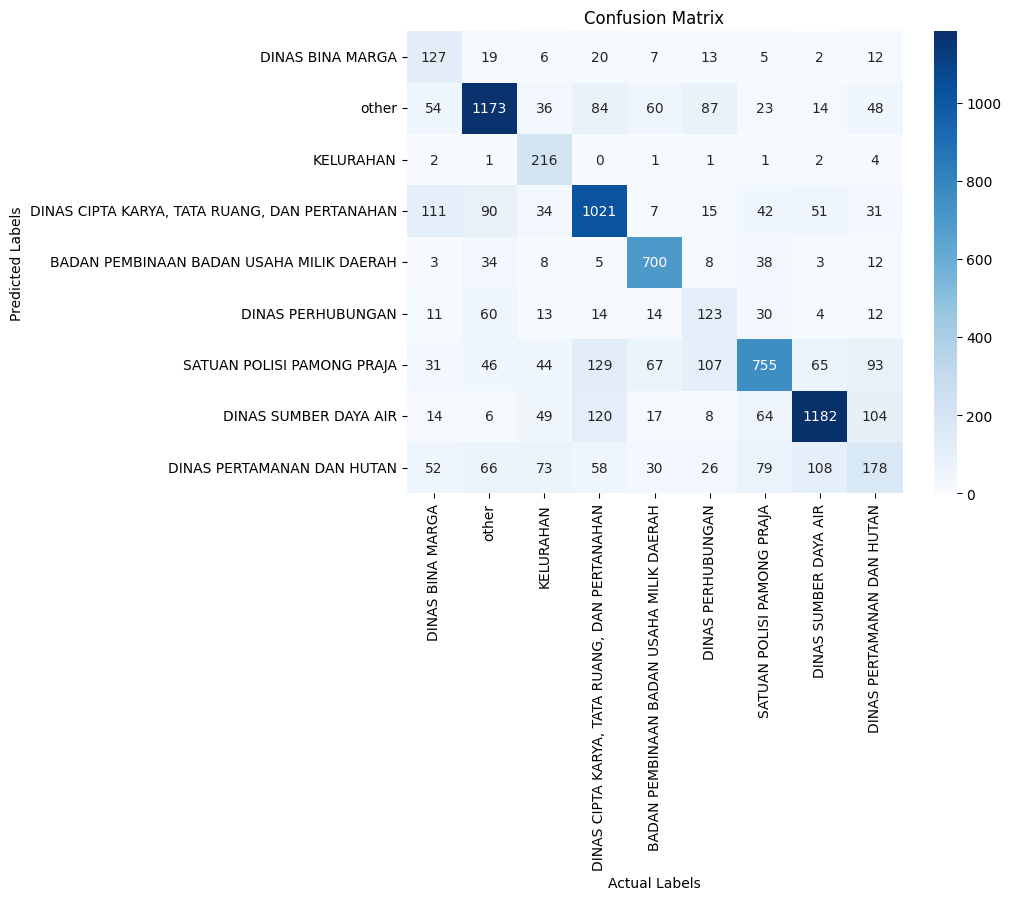

In [ ]:
evaluate_model(cb_model, test_df, 'dinas_final', 'label')

### DINOv2 + Cendol mT5 Multimodal Early Fusion

In [ ]:
with open(f'{DATA_DIR}/cendol-mt5-large-inst.pkl', 'rb') as f:
    df["text_embed"] = pickle.load(f).text_embed
with open(f'{DATA_DIR}/DINOv2-large-pretrained.pkl', 'rb') as f:
    df["img_embed"] = pickle.load(f).image_embedding

df.head()

,report_id,number,date,month,year,image_path,description,location,category,dinas,dinas_clean,image,dinas_final,img_embed_flava,img_embed_flava_v1,text_embed,img_embed
0,JK2301010001,1,1,1,23,JK2301010001.jpg,tolong nyalakn lampu pju sering terjadi tawura...,KELURAHAN KALI BARU,Jalan,DINAS BINA MARGA,DINAS BINA MARGA,/kaggle/input/gemastik2024/photo/photo/JK23010...,DINAS BINA MARGA,"[0.06608283, 0.048387114, -0.0041758493, 0.028...","[0.06608283, 0.048387114, -0.0041758493, 0.028...","[0.09056297, 0.05615388, -0.119688824, 0.04499...","[-0.83083415, 1.9883738, 1.20237, -1.2331511, ..."
1,JK2301010002,2,1,1,23,JK2301010002.jpg,mohon di cek dan di tindak sesuai peraturan ap...,KELURAHAN ROROTAN,Gangguan Ketenteraman dan Ketertiban,"DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN","DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN",/kaggle/input/gemastik2024/photo/photo/JK23010...,"DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN","[-0.02130023, 0.0035175434, -0.071640246, 0.01...","[-0.02130023, 0.0035175434, -0.071640246, 0.01...","[0.13310267, 0.070461385, -0.040767223, 0.0144...","[2.6261952, 0.4266512, 0.7405095, 0.037347347,..."
2,JK2301010003,3,1,1,23,JK2301010003.jpg,Selama ada nya plang segel masih berlanjut kar...,KELURAHAN ROROTAN,Gangguan Ketenteraman dan Ketertiban,"DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN","DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN",/kaggle/input/gemastik2024/photo/photo/JK23010...,"DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN","[-0.0833845, 0.04339636, -0.046543833, -0.0176...","[-0.0833845, 0.04339636, -0.046543833, -0.0176...","[-0.009591767, 0.007920389, -0.054674786, -0.0...","[2.77123, -2.5427809, 0.120608784, 1.556907, -..."
3,JK2301010006,6,1,1,23,JK2301010006.jpg,tolong diperbaiki lampu jalan utama terimakasi...,KELURAHAN SEMANAN,Pekerja Penanganan Prasarana dan Sarana Umum K...,DINAS BINA MARGA,DINAS BINA MARGA,/kaggle/input/gemastik2024/photo/photo/JK23010...,DINAS BINA MARGA,"[0.00654995, 0.010241772, -0.014649827, 0.1304...","[0.00654995, 0.010241772, -0.014649827, 0.1304...","[0.06634824, 0.09351404, -0.064733766, 0.00200...","[0.375469, 0.45676208, 1.4164181, -1.0512489, ..."
4,JK2301010007,7,1,1,23,JK2301010007.jpg,tolong diperbaiki lampu jalan utama terimakasi...,KELURAHAN SEMANAN,Pekerja Penanganan Prasarana dan Sarana Umum K...,DINAS BINA MARGA,DINAS BINA MARGA,/kaggle/input/gemastik2024/photo/photo/JK23010...,DINAS BINA MARGA,"[0.026130462, 0.04480181, -0.016486637, 0.1214...","[0.026130462, 0.04480181, -0.016486637, 0.1214...","[0.07893172, 0.08947854, -0.050831888, 0.00938...","[1.9118149, -0.22906148, 1.0710745, -2.714306,..."


In [ ]:
# Split the DataFrame into training and validation sets to 70% train, 15% validation, and 15% test
train_df, test_df = train_test_split(df, test_size=0.3, stratify=df['dinas_final'], random_state=42)
val_df, test_df = train_test_split(test_df, test_size=0.5, stratify=test_df['dinas_final'], random_state=42)

print(f"Train size: {train_df.shape}")
print(f"Validation size: {val_df.shape}")
print(f"Test size: {test_df.shape}")

Train size: (37719, 17)
Validation size: (8083, 17)
Test size: (8083, 17)


In [ ]:
train_df.reset_index(drop=True, inplace=True)
val_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

embed_feat = ["text_embed", "img_embed"]
feature_names = embed_feat

train_pool = Pool(
    data=train_df[embed_feat].to_numpy(),
    label=train_df['dinas_final'].to_numpy(),
    embedding_features=embed_feat,
    feature_names=embed_feat
)

val_pool = Pool(
    data=val_df[embed_feat].to_numpy(),
    label=val_df['dinas_final'].to_numpy(),
    embedding_features=embed_feat,
    feature_names=embed_feat
)

In [ ]:
class_weights_dict = dict()
n, num_class = train_df.shape[0], len(train_df['dinas_final'].unique())
for label in train_df['dinas_final'].unique():
    n_l = train_df[train_df['dinas_final'] == label].shape[0]
    class_weights_dict[label] = n / (num_class * n_l)

class_weights_dict

{'DINAS BINA MARGA': 0.5688110749185668,
 'other': 1.3389776357827476,
 'KELURAHAN': 0.6716346153846153,
 'DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN': 3.942615239887112,
 'BADAN PEMBINAAN BADAN USAHA MILIK DAERAH': 4.267820773930754,
 'DINAS PERHUBUNGAN': 0.6402383134738772,
 'SATUAN POLISI PAMONG PRAJA': 0.5743456214882828,
 'DINAS SUMBER DAYA AIR': 3.199236641221374,
 'DINAS PERTAMANAN DAN HUTAN': 1.1078509119746234}

In [ ]:
cb_model = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='Accuracy',
    task_type="GPU",
    devices="0",
    verbose=100,
    random_state=42,
    class_weights = class_weights_dict,
    learning_rate=0.01
)

cb_model.fit(
    train_pool,
    eval_set=val_pool
)

0:	learn: 0.5215416	test: 0.5606445	best: 0.5606445 (0)	total: 22.9ms	remaining: 22.9s
100:	learn: 0.6435437	test: 0.6717960	best: 0.6719037 (95)	total: 1.25s	remaining: 11.1s
200:	learn: 0.6663431	test: 0.7003973	best: 0.7003973 (200)	total: 2.34s	remaining: 9.31s
300:	learn: 0.6812368	test: 0.7126003	best: 0.7126252 (296)	total: 3.44s	remaining: 8s
400:	learn: 0.6916442	test: 0.7209673	best: 0.7213180 (399)	total: 4.58s	remaining: 6.85s
500:	learn: 0.6988475	test: 0.7250789	best: 0.7258012 (477)	total: 5.72s	remaining: 5.7s
600:	learn: 0.7055664	test: 0.7273600	best: 0.7278969 (594)	total: 7.08s	remaining: 4.7s
700:	learn: 0.7094015	test: 0.7302302	best: 0.7304717 (698)	total: 8.19s	remaining: 3.49s
800:	learn: 0.7115881	test: 0.7308708	best: 0.7308708 (798)	total: 9.29s	remaining: 2.31s
900:	learn: 0.7153528	test: 0.7328976	best: 0.7328976 (900)	total: 10.4s	remaining: 1.14s
999:	learn: 0.7194902	test: 0.7344029	best: 0.7352688 (986)	total: 11.5s	remaining: 0us
bestTest = 0.73526876

In [ ]:
test_pred = cb_model.predict(test_df[feature_names])
test_df['label'] = np.array(test_pred).reshape(-1)
test_df.head()

,report_id,number,date,month,year,image_path,description,location,category,dinas,dinas_clean,image,dinas_final,img_embed_flava,img_embed_flava_v1,text_embed,img_embed,label
0,JK2306180342,342,18,6,23,JK2306180342.jpg,"turunkan semua spanduk liar, merusak keindahan...",KELURAHAN KLENDER,"Keluhan Fasilitas Gedung Pemda (sekolah, kantor)",SATUAN POLISI PAMONG PRAJA,SATUAN POLISI PAMONG PRAJA,/kaggle/input/gemastik2024/photo/photo/JK23061...,SATUAN POLISI PAMONG PRAJA,"[-0.042070124, 0.05262886, -0.065062255, -0.00...","[-0.042070124, 0.05262886, -0.065062255, -0.00...","[0.06456372, 0.02033593, -0.071318015, 0.01529...","[1.6455362, -0.9255953, 0.817816, 0.6802739, 0...",SATUAN POLISI PAMONG PRAJA
1,JK2308260141,141,26,8,23,JK2308260141.jpg,segera diasphal dsdi patokan jln prof satrio n...,KELURAHAN KARET SEMANGGI,Jalan,UNIT PERALATAN DAN PERBEKALAN BINA MARGA,DINAS BINA MARGA,/kaggle/input/gemastik2024/photo/photo/JK23082...,DINAS BINA MARGA,"[-0.02845743, 0.024209492, -0.027055703, -0.07...","[-0.02845743, 0.024209492, -0.027055703, -0.07...","[0.023498751, 0.027393224, -0.045266606, -0.01...","[0.91373414, -1.7789384, -1.6952429, -0.565982...",DINAS BINA MARGA
2,JK2311250441,441,25,11,23,JK2311250441.jpg,Parkir liar di bahu jalan memakan hampir 2 laj...,KELURAHAN CIPINANG BESAR SELATAN,Parkir Liar,DINAS PERHUBUNGAN,DINAS PERHUBUNGAN,/kaggle/input/gemastik2024/photo/photo/JK23112...,DINAS PERHUBUNGAN,"[0.04832907, 0.019501302, -0.020758469, -0.035...","[0.04832907, 0.019501302, -0.020758469, -0.035...","[-0.009187295, -0.009120483, 0.012926119, -0.0...","[2.7343504, -2.3846152, 2.2076159, -0.08523672...",DINAS PERHUBUNGAN
3,JK2304090106,106,9,4,23,JK2304090106.jpg,Ketika Suku Badan Kesatuan Bangsa dan politik ...,KELURAHAN CIBUBUR,Perizinan,SATUAN POLISI PAMONG PRAJA,SATUAN POLISI PAMONG PRAJA,/kaggle/input/gemastik2024/photo/photo/JK23040...,SATUAN POLISI PAMONG PRAJA,"[-0.011295048, -0.0055511803, -0.028427957, -0...","[-0.011295048, -0.0055511803, -0.028427957, -0...","[0.0022210174, 0.0045210947, -0.02429384, -0.0...","[1.7590145, -0.9358065, -0.14855349, -0.039757...",SATUAN POLISI PAMONG PRAJA
4,JK2309010379,379,1,9,23,JK2309010379.jpg,tolong ini mobil motor di bahu jalan belum law...,KELURAHAN SRENGSENG SAWAH,Jalan,DINAS PERHUBUNGAN,DINAS PERHUBUNGAN,/kaggle/input/gemastik2024/photo/photo/JK23090...,DINAS PERHUBUNGAN,"[0.032454036, -0.07366714, -0.06683984, 0.0583...","[0.032454036, -0.07366714, -0.06683984, 0.0583...","[0.05521235, -0.032705072, -0.0032434952, -0.0...","[0.99790007, -1.2546221, -0.5877326, 0.4530511...",DINAS PERHUBUNGAN


Accuracy:  0.7498453544476061
Balanced Accuracy: 0.7391933885352315
Classification Report:
                                               precision    recall  f1-score   support

                             DINAS BINA MARGA       0.47      0.67      0.55       211
                                        other       0.84      0.80      0.82      1579
                                    KELURAHAN       0.67      0.95      0.79       228
DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN       0.77      0.82      0.79      1402
     BADAN PEMBINAAN BADAN USAHA MILIK DAERAH       0.86      0.91      0.88       811
                            DINAS PERHUBUNGAN       0.44      0.70      0.54       281
                   SATUAN POLISI PAMONG PRAJA       0.74      0.63      0.68      1337
                        DINAS SUMBER DAYA AIR       0.85      0.81      0.83      1564
                   DINAS PERTAMANAN DAN HUTAN       0.45      0.36      0.40       670

                                     

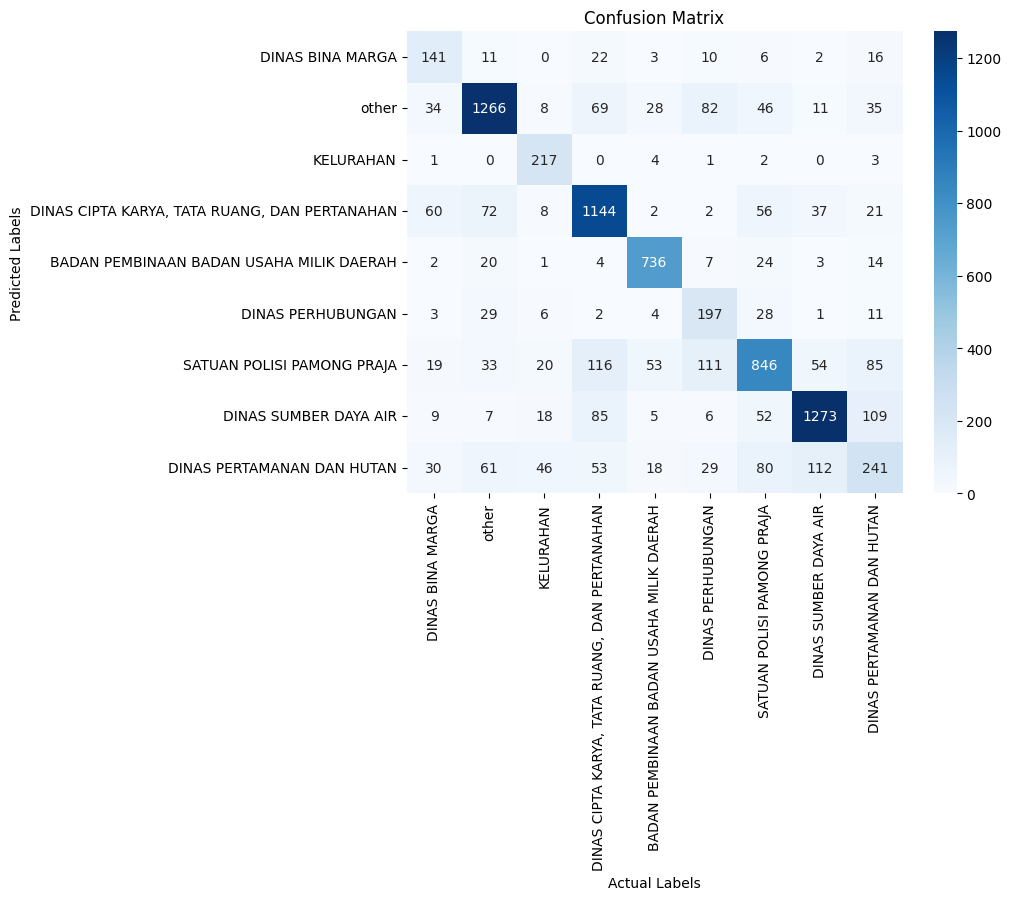

In [ ]:
evaluate_model(cb_model, test_df, 'dinas_final', 'label')

### ResNet-50 + fastText Embedding

In [ ]:
with open(f'{DATA_DIR}/fast-text.pkl', 'rb') as f:
    df["text_embed"] = pickle.load(f).text_embed
with open(f'{DATA_DIR}/Resnet-50.pkl', 'rb') as f:
    df["img_embed"] = pickle.load(f).image_embedding

df.head()

,report_id,number,date,month,year,image_path,description,location,category,dinas,dinas_clean,image,dinas_final,img_embed_flava,img_embed_flava_v1,text_embed,img_embed
0,JK2301010001,1,1,1,23,JK2301010001.jpg,tolong nyalakn lampu pju sering terjadi tawura...,KELURAHAN KALI BARU,Jalan,DINAS BINA MARGA,DINAS BINA MARGA,/kaggle/input/gemastik2024/photo/photo/JK23010...,DINAS BINA MARGA,"[0.06608283, 0.048387114, -0.0041758493, 0.028...","[0.06608283, 0.048387114, -0.0041758493, 0.028...","[0.0025286467, 0.002155527, 0.0040332894, 0.01...","[0.029536173, 0.04592556, 0.0, 0.2682214, 0.01..."
1,JK2301010002,2,1,1,23,JK2301010002.jpg,mohon di cek dan di tindak sesuai peraturan ap...,KELURAHAN ROROTAN,Gangguan Ketenteraman dan Ketertiban,"DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN","DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN",/kaggle/input/gemastik2024/photo/photo/JK23010...,"DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN","[-0.02130023, 0.0035175434, -0.071640246, 0.01...","[-0.02130023, 0.0035175434, -0.071640246, 0.01...","[-0.0011756993, 0.0003717459, 0.003883138, 0.0...","[1.1589612, 0.35638598, 0.7302971, 0.023119228..."
2,JK2301010003,3,1,1,23,JK2301010003.jpg,Selama ada nya plang segel masih berlanjut kar...,KELURAHAN ROROTAN,Gangguan Ketenteraman dan Ketertiban,"DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN","DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN",/kaggle/input/gemastik2024/photo/photo/JK23010...,"DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN","[-0.0833845, 0.04339636, -0.046543833, -0.0176...","[-0.0833845, 0.04339636, -0.046543833, -0.0176...","[0.004447728, 0.0007556947, 0.0027799844, 0.01...","[0.5235181, 0.5559952, 0.023369603, 3.34001, 0..."
3,JK2301010006,6,1,1,23,JK2301010006.jpg,tolong diperbaiki lampu jalan utama terimakasi...,KELURAHAN SEMANAN,Pekerja Penanganan Prasarana dan Sarana Umum K...,DINAS BINA MARGA,DINAS BINA MARGA,/kaggle/input/gemastik2024/photo/photo/JK23010...,DINAS BINA MARGA,"[0.00654995, 0.010241772, -0.014649827, 0.1304...","[0.00654995, 0.010241772, -0.014649827, 0.1304...","[-0.00048696497, 0.007519939, 0.011277881, 0.0...","[0.66326123, 0.2108703, 0.3096287, 0.12897845,..."
4,JK2301010007,7,1,1,23,JK2301010007.jpg,tolong diperbaiki lampu jalan utama terimakasi...,KELURAHAN SEMANAN,Pekerja Penanganan Prasarana dan Sarana Umum K...,DINAS BINA MARGA,DINAS BINA MARGA,/kaggle/input/gemastik2024/photo/photo/JK23010...,DINAS BINA MARGA,"[0.026130462, 0.04480181, -0.016486637, 0.1214...","[0.026130462, 0.04480181, -0.016486637, 0.1214...","[-0.000592529, 0.007620225, 0.011189336, 0.023...","[0.03831262, 0.40262136, 0.7077466, 0.02358631..."


In [ ]:
# Split the DataFrame into training and validation sets to 70% train, 15% validation, and 15% test
train_df, test_df = train_test_split(df, test_size=0.3, stratify=df['dinas_final'], random_state=42)
val_df, test_df = train_test_split(test_df, test_size=0.5, stratify=test_df['dinas_final'], random_state=42)

print(f"Train size: {train_df.shape}")
print(f"Validation size: {val_df.shape}")
print(f"Test size: {test_df.shape}")

Train size: (37719, 17)
Validation size: (8083, 17)
Test size: (8083, 17)


In [ ]:
train_df.reset_index(drop=True, inplace=True)
val_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

embed_feat = ["text_embed", "img_embed"]
feature_names = embed_feat

train_pool = Pool(
    data=train_df[embed_feat].to_numpy(),
    label=train_df['dinas_final'].to_numpy(),
    embedding_features=embed_feat,
    feature_names=embed_feat
)

val_pool = Pool(
    data=val_df[embed_feat].to_numpy(),
    label=val_df['dinas_final'].to_numpy(),
    embedding_features=embed_feat,
    feature_names=embed_feat
)

In [ ]:
class_weights_dict = dict()
n, num_class = train_df.shape[0], len(train_df['dinas_final'].unique())
for label in train_df['dinas_final'].unique():
    n_l = train_df[train_df['dinas_final'] == label].shape[0]
    class_weights_dict[label] = n / (num_class * n_l)

class_weights_dict

{'DINAS BINA MARGA': 0.5688110749185668,
 'other': 1.3389776357827476,
 'KELURAHAN': 0.6716346153846153,
 'DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN': 3.942615239887112,
 'BADAN PEMBINAAN BADAN USAHA MILIK DAERAH': 4.267820773930754,
 'DINAS PERHUBUNGAN': 0.6402383134738772,
 'SATUAN POLISI PAMONG PRAJA': 0.5743456214882828,
 'DINAS SUMBER DAYA AIR': 3.199236641221374,
 'DINAS PERTAMANAN DAN HUTAN': 1.1078509119746234}

In [ ]:
cb_model = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='Accuracy',
    task_type="GPU",
    devices="0",
    verbose=100,
    random_state=42,
    class_weights = class_weights_dict,
    learning_rate=0.01
)

cb_model.fit(
    train_pool,
    eval_set=val_pool
)

0:	learn: 0.4517849	test: 0.4566749	best: 0.4566749 (0)	total: 24.6ms	remaining: 24.6s
100:	learn: 0.5780008	test: 0.5774713	best: 0.5777908 (98)	total: 1.27s	remaining: 11.3s
200:	learn: 0.6159601	test: 0.6272940	best: 0.6272940 (200)	total: 2.37s	remaining: 9.4s
300:	learn: 0.6310613	test: 0.6435229	best: 0.6435391 (297)	total: 3.48s	remaining: 8.09s
400:	learn: 0.6432489	test: 0.6515167	best: 0.6523356 (393)	total: 4.64s	remaining: 6.93s
500:	learn: 0.6531159	test: 0.6572856	best: 0.6572856 (500)	total: 5.75s	remaining: 5.73s
600:	learn: 0.6598174	test: 0.6625796	best: 0.6631002 (597)	total: 6.88s	remaining: 4.57s
700:	learn: 0.6678623	test: 0.6668679	best: 0.6668927 (661)	total: 8.01s	remaining: 3.42s
800:	learn: 0.6725786	test: 0.6679810	best: 0.6685123 (795)	total: 9.14s	remaining: 2.27s
900:	learn: 0.6763201	test: 0.6723484	best: 0.6729986 (893)	total: 10.3s	remaining: 1.13s
999:	learn: 0.6803671	test: 0.6738497	best: 0.6741082 (943)	total: 11.4s	remaining: 0us
bestTest = 0.6741

In [ ]:
test_pred = cb_model.predict(test_df[feature_names])
test_df['label'] = np.array(test_pred).reshape(-1)
test_df.head()

,report_id,number,date,month,year,image_path,description,location,category,dinas,dinas_clean,image,dinas_final,img_embed_flava,img_embed_flava_v1,text_embed,img_embed,label
0,JK2306180342,342,18,6,23,JK2306180342.jpg,"turunkan semua spanduk liar, merusak keindahan...",KELURAHAN KLENDER,"Keluhan Fasilitas Gedung Pemda (sekolah, kantor)",SATUAN POLISI PAMONG PRAJA,SATUAN POLISI PAMONG PRAJA,/kaggle/input/gemastik2024/photo/photo/JK23061...,SATUAN POLISI PAMONG PRAJA,"[-0.042070124, 0.05262886, -0.065062255, -0.00...","[-0.042070124, 0.05262886, -0.065062255, -0.00...","[0.0049139303, -0.00228165, 0.002385617, 0.000...","[0.0, 0.5013656, 0.49396217, 0.0, 0.01200202, ...",SATUAN POLISI PAMONG PRAJA
1,JK2308260141,141,26,8,23,JK2308260141.jpg,segera diasphal dsdi patokan jln prof satrio n...,KELURAHAN KARET SEMANGGI,Jalan,UNIT PERALATAN DAN PERBEKALAN BINA MARGA,DINAS BINA MARGA,/kaggle/input/gemastik2024/photo/photo/JK23082...,DINAS BINA MARGA,"[-0.02845743, 0.024209492, -0.027055703, -0.07...","[-0.02845743, 0.024209492, -0.027055703, -0.07...","[0.0021646733, -0.0014774933, 0.0036143076, 0....","[0.24754761, 0.3037243, 0.9344132, 0.0, 0.1672...",DINAS SUMBER DAYA AIR
2,JK2311250441,441,25,11,23,JK2311250441.jpg,Parkir liar di bahu jalan memakan hampir 2 laj...,KELURAHAN CIPINANG BESAR SELATAN,Parkir Liar,DINAS PERHUBUNGAN,DINAS PERHUBUNGAN,/kaggle/input/gemastik2024/photo/photo/JK23112...,DINAS PERHUBUNGAN,"[0.04832907, 0.019501302, -0.020758469, -0.035...","[0.04832907, 0.019501302, -0.020758469, -0.035...","[0.0058747646, -0.0027063896, 0.0031959307, 0....","[0.25660205, 0.0, 0.035766665, 0.00354055, 0.0...",DINAS PERHUBUNGAN
3,JK2304090106,106,9,4,23,JK2304090106.jpg,Ketika Suku Badan Kesatuan Bangsa dan politik ...,KELURAHAN CIBUBUR,Perizinan,SATUAN POLISI PAMONG PRAJA,SATUAN POLISI PAMONG PRAJA,/kaggle/input/gemastik2024/photo/photo/JK23040...,SATUAN POLISI PAMONG PRAJA,"[-0.011295048, -0.0055511803, -0.028427957, -0...","[-0.011295048, -0.0055511803, -0.028427957, -0...","[0.0043759868, 0.00095789053, 0.0049770395, 0....","[0.7230602, 0.19118944, 0.6504271, 0.7735851, ...",SATUAN POLISI PAMONG PRAJA
4,JK2309010379,379,1,9,23,JK2309010379.jpg,tolong ini mobil motor di bahu jalan belum law...,KELURAHAN SRENGSENG SAWAH,Jalan,DINAS PERHUBUNGAN,DINAS PERHUBUNGAN,/kaggle/input/gemastik2024/photo/photo/JK23090...,DINAS PERHUBUNGAN,"[0.032454036, -0.07366714, -0.06683984, 0.0583...","[0.032454036, -0.07366714, -0.06683984, 0.0583...","[0.0051840004, 0.0017418743, 0.005942822, 0.01...","[0.2444295, 0.22087747, 0.23359703, 0.0, 0.215...",DINAS PERHUBUNGAN


Accuracy:  0.6899665965606829
Balanced Accuracy: 0.671132615633679
Classification Report:
                                               precision    recall  f1-score   support

                             DINAS BINA MARGA       0.23      0.58      0.33       211
                                        other       0.78      0.75      0.77      1579
                                    KELURAHAN       0.59      0.91      0.72       228
DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN       0.73      0.76      0.74      1402
     BADAN PEMBINAAN BADAN USAHA MILIK DAERAH       0.82      0.87      0.84       811
                            DINAS PERHUBUNGAN       0.35      0.59      0.44       281
                   SATUAN POLISI PAMONG PRAJA       0.75      0.57      0.65      1337
                        DINAS SUMBER DAYA AIR       0.83      0.76      0.80      1564
                   DINAS PERTAMANAN DAN HUTAN       0.39      0.26      0.31       670

                                     a

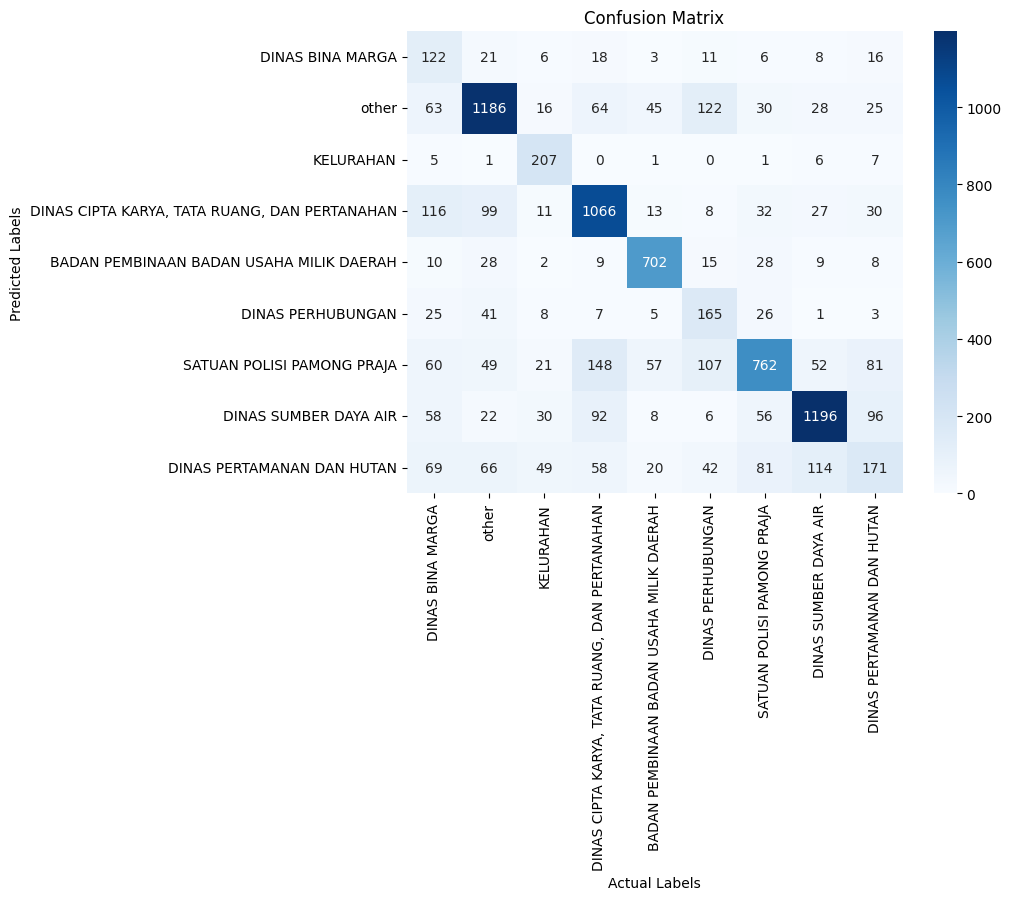

In [ ]:
evaluate_model(cb_model, test_df, 'dinas_final', 'label')

### ResNet-50 + IndoBERT Embedding

In [ ]:
with open(f'{DATA_DIR}/indo-bert.pkl', 'rb') as f:
    df["text_embed"] = pickle.load(f).text_embed
with open(f'{DATA_DIR}/Resnet-50.pkl', 'rb') as f:
    df["img_embed"] = pickle.load(f).image_embedding

df.head()

,report_id,number,date,month,year,image_path,description,location,category,dinas,dinas_clean,image,dinas_final,text_embed,img_embed
0,JK2301010001,1,1,1,23,JK2301010001.jpg,tolong nyalakn lampu pju sering terjadi tawura...,KELURAHAN KALI BARU,Jalan,DINAS BINA MARGA,DINAS BINA MARGA,/kaggle/input/gemastik2024/photo/photo/JK23010...,DINAS BINA MARGA,"[-0.13590446, -0.30751708, -0.683269, 0.686474...","[0.029536173, 0.04592556, 0.0, 0.2682214, 0.01..."
1,JK2301010002,2,1,1,23,JK2301010002.jpg,mohon di cek dan di tindak sesuai peraturan ap...,KELURAHAN ROROTAN,Gangguan Ketenteraman dan Ketertiban,"DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN","DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN",/kaggle/input/gemastik2024/photo/photo/JK23010...,"DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN","[-0.21154359, -0.44479522, -1.0618348, 0.46512...","[1.1589612, 0.35638598, 0.7302971, 0.023119228..."
2,JK2301010003,3,1,1,23,JK2301010003.jpg,Selama ada nya plang segel masih berlanjut kar...,KELURAHAN ROROTAN,Gangguan Ketenteraman dan Ketertiban,"DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN","DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN",/kaggle/input/gemastik2024/photo/photo/JK23010...,"DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN","[-0.073845275, -0.8334186, -0.26953578, 1.0449...","[0.5235181, 0.5559952, 0.023369603, 3.34001, 0..."
3,JK2301010006,6,1,1,23,JK2301010006.jpg,tolong diperbaiki lampu jalan utama terimakasi...,KELURAHAN SEMANAN,Pekerja Penanganan Prasarana dan Sarana Umum K...,DINAS BINA MARGA,DINAS BINA MARGA,/kaggle/input/gemastik2024/photo/photo/JK23010...,DINAS BINA MARGA,"[-1.0357008, -1.2108922, -1.651462, -0.5162849...","[0.66326123, 0.2108703, 0.3096287, 0.12897845,..."
4,JK2301010007,7,1,1,23,JK2301010007.jpg,tolong diperbaiki lampu jalan utama terimakasi...,KELURAHAN SEMANAN,Pekerja Penanganan Prasarana dan Sarana Umum K...,DINAS BINA MARGA,DINAS BINA MARGA,/kaggle/input/gemastik2024/photo/photo/JK23010...,DINAS BINA MARGA,"[-1.0178334, -1.1703733, -1.4693449, -0.491842...","[0.03831262, 0.40262136, 0.7077466, 0.02358631..."


In [ ]:
# Split the DataFrame into training and validation sets to 70% train, 15% validation, and 15% test
train_df, test_df = train_test_split(df, test_size=0.3, stratify=df['dinas_final'], random_state=42)
val_df, test_df = train_test_split(test_df, test_size=0.5, stratify=test_df['dinas_final'], random_state=42)

print(f"Train size: {train_df.shape}")
print(f"Validation size: {val_df.shape}")
print(f"Test size: {test_df.shape}")

Train size: (37719, 15)
Validation size: (8083, 15)
Test size: (8083, 15)


In [ ]:
train_df.reset_index(drop=True, inplace=True)
val_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

embed_feat = ["text_embed", "img_embed"]
feature_names = embed_feat

train_pool = Pool(
    data=train_df[embed_feat].to_numpy(),
    label=train_df['dinas_final'].to_numpy(),
    embedding_features=embed_feat,
    feature_names=embed_feat
)

val_pool = Pool(
    data=val_df[embed_feat].to_numpy(),
    label=val_df['dinas_final'].to_numpy(),
    embedding_features=embed_feat,
    feature_names=embed_feat
)

In [ ]:
class_weights_dict = dict()
n, num_class = train_df.shape[0], len(train_df['dinas_final'].unique())
for label in train_df['dinas_final'].unique():
    n_l = train_df[train_df['dinas_final'] == label].shape[0]
    class_weights_dict[label] = n / (num_class * n_l)

class_weights_dict

{'DINAS BINA MARGA': 0.5688110749185668,
 'other': 1.3389776357827476,
 'KELURAHAN': 0.6716346153846153,
 'DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN': 3.942615239887112,
 'BADAN PEMBINAAN BADAN USAHA MILIK DAERAH': 4.267820773930754,
 'DINAS PERHUBUNGAN': 0.6402383134738772,
 'SATUAN POLISI PAMONG PRAJA': 0.5743456214882828,
 'DINAS SUMBER DAYA AIR': 3.199236641221374,
 'DINAS PERTAMANAN DAN HUTAN': 1.1078509119746234}

In [ ]:
cb_model = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='Accuracy',
    task_type="GPU",
    devices="0",
    verbose=100,
    random_state=42,
    class_weights = class_weights_dict,
    learning_rate=0.01
)

cb_model.fit(
    train_pool,
    eval_set=val_pool
)

0:	learn: 0.4457987	test: 0.4749226	best: 0.4749226 (0)	total: 162ms	remaining: 2m 42s
100:	learn: 0.5698695	test: 0.5759536	best: 0.5759536 (100)	total: 1.43s	remaining: 12.7s
200:	learn: 0.6062287	test: 0.6130864	best: 0.6130864 (200)	total: 2.53s	remaining: 10.1s
300:	learn: 0.6251237	test: 0.6283315	best: 0.6289728 (298)	total: 3.72s	remaining: 8.65s
400:	learn: 0.6370494	test: 0.6353129	best: 0.6355024 (398)	total: 4.95s	remaining: 7.4s
500:	learn: 0.6489897	test: 0.6398739	best: 0.6398739 (500)	total: 6.07s	remaining: 6.04s
600:	learn: 0.6568156	test: 0.6412061	best: 0.6421771 (595)	total: 7.17s	remaining: 4.76s
700:	learn: 0.6631000	test: 0.6424205	best: 0.6424205 (700)	total: 8.32s	remaining: 3.55s
800:	learn: 0.6681757	test: 0.6408579	best: 0.6427494 (712)	total: 9.43s	remaining: 2.34s
900:	learn: 0.6730844	test: 0.6395815	best: 0.6427494 (712)	total: 10.5s	remaining: 1.16s
999:	learn: 0.6771425	test: 0.6369276	best: 0.6427494 (712)	total: 11.6s	remaining: 0us
bestTest = 0.642

In [ ]:
test_pred = cb_model.predict(test_df[feature_names])
test_df['label'] = np.array(test_pred).reshape(-1)
test_df.head()

,report_id,number,date,month,year,image_path,description,location,category,dinas,dinas_clean,image,dinas_final,text_embed,img_embed,label
0,JK2306180342,342,18,6,23,JK2306180342.jpg,"turunkan semua spanduk liar, merusak keindahan...",KELURAHAN KLENDER,"Keluhan Fasilitas Gedung Pemda (sekolah, kantor)",SATUAN POLISI PAMONG PRAJA,SATUAN POLISI PAMONG PRAJA,/kaggle/input/gemastik2024/photo/photo/JK23061...,SATUAN POLISI PAMONG PRAJA,"[0.17814675, -1.3693159, -1.337474, 0.694516, ...","[0.0, 0.5013656, 0.49396217, 0.0, 0.01200202, ...",SATUAN POLISI PAMONG PRAJA
1,JK2308260141,141,26,8,23,JK2308260141.jpg,segera diasphal dsdi patokan jln prof satrio n...,KELURAHAN KARET SEMANGGI,Jalan,UNIT PERALATAN DAN PERBEKALAN BINA MARGA,DINAS BINA MARGA,/kaggle/input/gemastik2024/photo/photo/JK23082...,DINAS BINA MARGA,"[0.44842422, -1.0373389, -1.121876, 0.7094506,...","[0.24754761, 0.3037243, 0.9344132, 0.0, 0.1672...",BADAN PEMBINAAN BADAN USAHA MILIK DAERAH
2,JK2311250441,441,25,11,23,JK2311250441.jpg,Parkir liar di bahu jalan memakan hampir 2 laj...,KELURAHAN CIPINANG BESAR SELATAN,Parkir Liar,DINAS PERHUBUNGAN,DINAS PERHUBUNGAN,/kaggle/input/gemastik2024/photo/photo/JK23112...,DINAS PERHUBUNGAN,"[-0.40145233, -1.1081033, -0.6192979, 0.074970...","[0.25660205, 0.0, 0.035766665, 0.00354055, 0.0...",DINAS PERHUBUNGAN
3,JK2304090106,106,9,4,23,JK2304090106.jpg,Ketika Suku Badan Kesatuan Bangsa dan politik ...,KELURAHAN CIBUBUR,Perizinan,SATUAN POLISI PAMONG PRAJA,SATUAN POLISI PAMONG PRAJA,/kaggle/input/gemastik2024/photo/photo/JK23040...,SATUAN POLISI PAMONG PRAJA,"[-0.0045232563, -0.37142956, -0.6458214, 0.472...","[0.7230602, 0.19118944, 0.6504271, 0.7735851, ...",SATUAN POLISI PAMONG PRAJA
4,JK2309010379,379,1,9,23,JK2309010379.jpg,tolong ini mobil motor di bahu jalan belum law...,KELURAHAN SRENGSENG SAWAH,Jalan,DINAS PERHUBUNGAN,DINAS PERHUBUNGAN,/kaggle/input/gemastik2024/photo/photo/JK23090...,DINAS PERHUBUNGAN,"[-0.27933827, -1.0244696, -1.356721, 0.3055492...","[0.2444295, 0.22087747, 0.23359703, 0.0, 0.215...",DINAS PERHUBUNGAN


Accuracy:  0.6674502041321292
Balanced Accuracy: 0.6512794618072094
Classification Report:
                                               precision    recall  f1-score   support

                             DINAS BINA MARGA       0.18      0.49      0.27       211
                                        other       0.79      0.70      0.74      1579
                                    KELURAHAN       0.64      0.92      0.76       228
DINAS CIPTA KARYA, TATA RUANG, DAN PERTANAHAN       0.70      0.74      0.72      1402
     BADAN PEMBINAAN BADAN USAHA MILIK DAERAH       0.79      0.85      0.82       811
                            DINAS PERHUBUNGAN       0.32      0.55      0.41       281
                   SATUAN POLISI PAMONG PRAJA       0.74      0.52      0.61      1337
                        DINAS SUMBER DAYA AIR       0.84      0.75      0.80      1564
                   DINAS PERTAMANAN DAN HUTAN       0.35      0.33      0.34       670

                                     

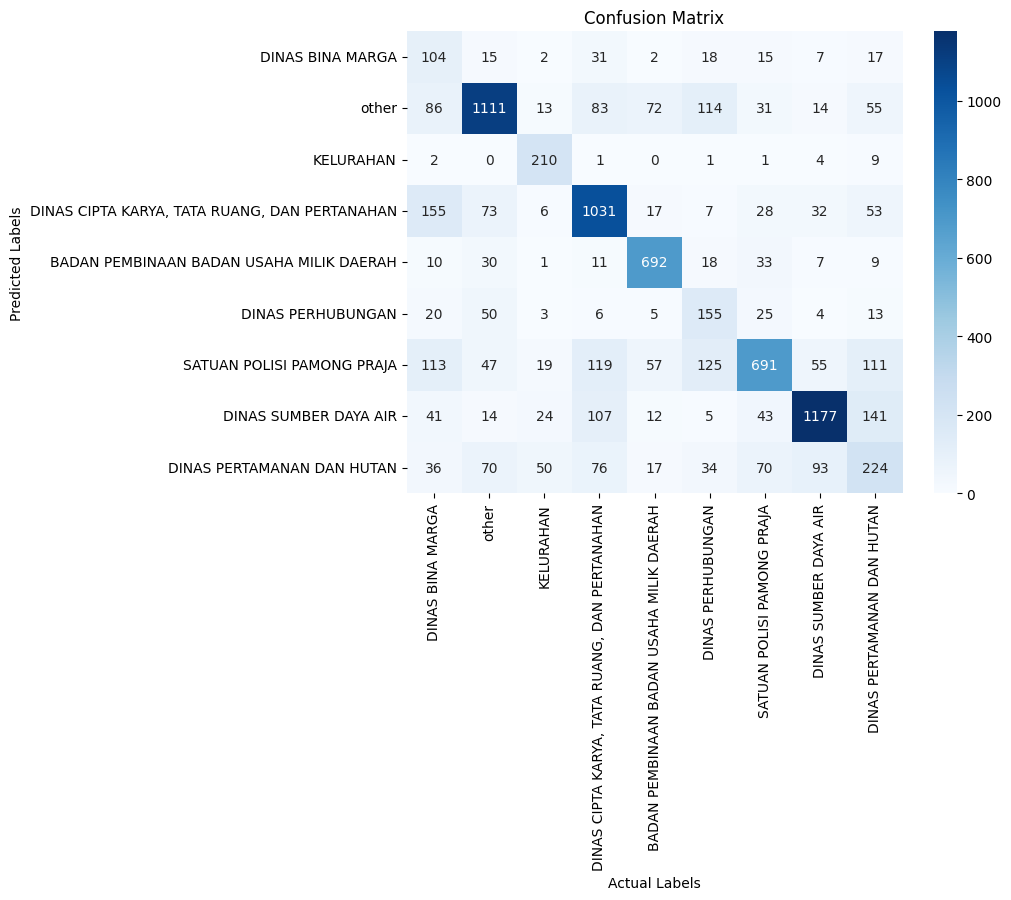

In [ ]:
evaluate_model(cb_model, test_df, 'dinas_final', 'label')